<h1 style="text-align: center;">Fraud Detections & Data Quality Analysis Of GrabUnlimited Transactions In GrabFood</h1>
<h3 style="text-align: center;">Zian Carlos Wong & Valencia</h3>

---

In [114]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import shapiro
from scipy.stats import ttest_ind, mannwhitneyu


In [115]:
df_food_orders_raw = pd.read_csv("../data/raw/grab_food_orders.csv")
df_merchants_raw = pd.read_csv("../data/raw/grab_merchants.csv")
df_users_raw = pd.read_csv("../data/raw/grab_users.csv")

df_food_orders_cleaned = df_food_orders_raw.copy()
df_merchants_cleaned = df_merchants_raw.copy()
df_users_cleaned = df_users_raw.copy()

In [116]:
df_food_orders_cleaned.head()

,order_id,merchant_id,user_id,order_status,promo_discount,cancel_reason,order_time,driver_arrived_time,completed_time
0,GF-ORD-00000001,GF-06555,GB-019659,Completed,0,NaN,2023-12-21 09:43:00,2023-12-21 10:00:00,2023-12-21 10:16:00
1,GF-ORD-00000002,GF-07698,GB-019520,Cancel,0,Resto Tidak Ditemukan,2023-12-20 14:01:00,2023-12-20 14:13:00,NaN
2,GF-ORD-00000003,GF-02054,GB-030006,CANCELED,15000,Menu Habis,2024-02-18 12:56:00,2024-02-18 13:06:00,NaN
3,GF-ORD-00000004,GF-05867,GB-021929,Completed,30000,NaN,2023-12-21 16:12:00,2023-12-21 16:24:00,2023-12-21 16:58:00
4,GF-ORD-00000005,GF-06915,GB-008802,DONE,0,NaN,2024-02-03 09:13:00,2024-02-03 09:20:00,2024-02-03 09:36:00


In [117]:
df_merchants_cleaned.head()

,merchant_id,merchant_name,cuisine_type,city
0,GF-00001,Resto GrabMantap 0,Seafood,Depok
1,GF-00002,Resto GrabMantap 1,Fast Food,Surabaya
2,GF-00003,Resto GrabMantap 2,Martabak,Tangerang
3,GF-00004,Resto GrabMantap 3,Martabak,Jakarta
4,GF-00005,Resto GrabMantap 4,Snacks,Bekasi


In [118]:
df_users_cleaned.head()

,user_id,is_grab_unlimited,account_age_days
0,GB-000001,False,91
1,GB-000002,False,1048
2,GB-000003,True,985
3,GB-000004,True,1357
4,GB-000005,False,16


## **Section 1. Business Context**

**1.1 Context**

**Grab launched GrabUnlimited**, a subscription program designed to improve customer retention by offering free delivery vouchers and food discounts through a monthly membership. While the program successfully increased transaction frequency, it also became a target for fraud. **Fraudsters created fictitious restaurants and placed fake food orders to abuse promotional subsidies**, causing significant financial losses from food discounts, delivery subsidies, and **cancelled orders that also affected operational performance metrics.**

At the same time, the Data Engineering and Fraud teams faced challenges in detecting fraudulent activity due to poor data quality. Cancellation reasons were often missing or inconsistent, and a system issue allowed some orders to be marked as completed before the driver arrived at the pickup location. These data limitations made fraud investigations less effective and highlighted the need for data analysis to identify suspicious transaction patterns associated with GrabUnlimited usage.

**1.2 Problem Statements**

**Main Problem**: Grab faces significant financial loss due to GrabUnlimited subsidy exploitation by fraudulent restaurant and high cancellation rate

**Derived Problems**
1.	Which merchant have very high success rate but only 2-3 repeating customers?
2.	How many subsidy money from GrabUnlimited promo is wasted on suspicious fake transactions?
3.	How inconsistent and unstandardized the database?
4.	What percentage of canceled orders have missing cancellation reasons?
5.	How many completed orders show completion time earlier than driver arrival time?
6.	Which food categories are most often used by fake restaurants to inflate prices?


**1.3 Key Objective**

- Objective 1: Identify merchants suspected of being fake restaurants set up to exploit GrabUnlimited promo subsidies.
- Objective 2: Estimate the financial loss from promo subsidies wasted on fraudulent transactions.
- Objective 3: Clean and standardize inconsistent data (order status, cancellation reasons, missing values) to support reliable fraud investigation.
- Objective 4: Detect anomalies in order timestamps and promo usage patterns, and use them to flag high-risk merchants and users.

## **Section 2. Data Understanding**

**2.1 General Information**

In [119]:
df_food_orders_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   order_id             300000 non-null  object
 1   merchant_id          300000 non-null  object
 2   user_id              300000 non-null  object
 3   order_status         300000 non-null  object
 4   promo_discount       300000 non-null  int64 
 5   cancel_reason        35780 non-null   object
 6   order_time           300000 non-null  object
 7   driver_arrived_time  270320 non-null  object
 8   completed_time       240093 non-null  object
dtypes: int64(1), object(8)
memory usage: 20.6+ MB


In [120]:
df_merchants_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   merchant_id    8000 non-null   object
 1   merchant_name  8000 non-null   object
 2   cuisine_type   8000 non-null   object
 3   city           8000 non-null   object
dtypes: object(4)
memory usage: 250.1+ KB


In [121]:
df_users_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   user_id            40000 non-null  object
 1   is_grab_unlimited  40000 non-null  bool  
 2   account_age_days   40000 non-null  int64 
dtypes: bool(1), int64(1), object(1)
memory usage: 664.2+ KB


In [122]:
print("food orders table shape:", df_food_orders_cleaned.shape)
print("merchant table shape:", df_merchants_cleaned.shape)
print("users table shape:", df_users_cleaned.shape)

food orders table shape: (300000, 9)
merchant table shape: (8000, 4)
users table shape: (40000, 3)


**2.2 Feature Information**

In [123]:
print("Food orders Table list of colums:", df_food_orders_cleaned.columns.tolist())
print("Merchants Table list of colums:", df_merchants_cleaned.columns.tolist())
print("Users Table list of colums:", df_users_cleaned.columns.tolist())


Food orders Table list of colums: ['order_id', 'merchant_id', 'user_id', 'order_status', 'promo_discount', 'cancel_reason', 'order_time', 'driver_arrived_time', 'completed_time']
Merchants Table list of colums: ['merchant_id', 'merchant_name', 'cuisine_type', 'city']
Users Table list of colums: ['user_id', 'is_grab_unlimited', 'account_age_days']


In [124]:
print("Food Orders Table Each Column Null Values Sum")
display(df_food_orders_cleaned.isnull().sum())


Food Orders Table Each Column Null Values Sum


order_id                    0
merchant_id                 0
user_id                     0
order_status                0
promo_discount              0
cancel_reason          264220
order_time                  0
driver_arrived_time     29680
completed_time          59907
dtype: int64

In [125]:
print("Merchants Table Each Column Null Values Sum")
display(df_merchants_cleaned.isnull().sum())


Merchants Table Each Column Null Values Sum


merchant_id      0
merchant_name    0
cuisine_type     0
city             0
dtype: int64

In [126]:
print("Users Table Each Column Null Values Sum")
display(df_users_cleaned.isnull().sum())


Users Table Each Column Null Values Sum


user_id              0
is_grab_unlimited    0
account_age_days     0
dtype: int64

**2.3 Statistics Summary**

In [127]:
df_food_orders_cleaned.describe()

,promo_discount
count,3.000000e+05
mean,6.035158e+04
std,7.018429e+05
min,-5.000000e+03
25%,0.000000e+00
50%,1.000000e+04
75%,2.000000e+04
max,9.999999e+06


In [128]:
df_merchants_cleaned.describe()

,merchant_id,merchant_name,cuisine_type,city
count,8000,8000,8000,8000
unique,8000,8000,6,10
top,GF-00001,Resto GrabMantap 0,Ayam Geprek,Bekasi
freq,1,1,1388,861


In [129]:
df_users_cleaned.describe()

,account_age_days
count,40000.000000
mean,750.897150
std,431.156788
min,1.000000
25%,378.000000
50%,753.000000
75%,1122.000000
max,1499.000000


## **Section 3. Data Cleaning**

**3.1 Duplicated Values**

In [130]:
# (3.1.1.1) Check duplicate rows in dataset
# Step: Identify fully duplicated records across all columns

print("Food Orders Duplicated Rows:", df_food_orders_cleaned.duplicated().sum())
print("Merchants Duplicated Rows:",df_merchants_cleaned.duplicated().sum())
print("Users Duplicated Rows:",df_users_cleaned.duplicated().sum())

Food Orders Duplicated Rows: 0
Merchants Duplicated Rows: 0
Users Duplicated Rows: 0


In [131]:
# (3.1.2.1) Check duplicate rows in dataset primary key & must unique columns
# Step: Identify fully duplicated records across all columns

print("Food Orders Primary Key Is Unique:", df_food_orders_cleaned["order_id"].is_unique)
print("Merchants Id Primary Key Is Unique:",df_merchants_cleaned["merchant_id"].is_unique)
print("Merchants Name Is Unique:",df_merchants_cleaned["merchant_name"].is_unique)
print("Users Primary Key Is Unique:",df_users_cleaned["user_id"].is_unique)

Food Orders Primary Key Is Unique: True
Merchants Id Primary Key Is Unique: True
Merchants Name Is Unique: True
Users Primary Key Is Unique: True


**3.2 Identify Spelling Errors**

In [132]:
# (3.2.1.1) Identify spelling inconsistencies in the 'order_status' feature
# Step 1:
# Check the unique values to identify inconsistent spellings,
# capitalization, or synonyms.

print("Unique values in 'order_status':")
print(df_food_orders_cleaned["order_status"].unique())

Unique values in 'order_status':
['Completed' 'Cancel' 'CANCELED' 'DONE' 'Selesai' 'batal' 'Failed']


In [133]:
# (3.2.1.2) Standardize categorical values in 'order_status'
# Step 2: Normalize inconsistent labels due to spelling, casing, or language differences
# - Merge different representations of Completed, Cancelled, and Failed into a single standard format
# - This ensures consistent grouping for analysis and avoids duplicate categories

df_food_orders_cleaned["order_status"] = df_food_orders_cleaned["order_status"].replace({
    "Completed": "Completed",
    "DONE": "Completed",
    "Selesai": "Completed",

    "Cancel": "Cancelled",
    "CANCELED": "Cancelled",
    "batal": "Cancelled",

    "Failed": "Failed"
})

**3.3 Missing Values**

In [134]:
# (3.3.3.1) Analyze relationship between 'order_status' and 'cancel_reason'
# Step: Create a cross-tabulation to understand how cancellation reasons
#       are distributed across different order statuses
# - dropna=False ensures missing values are included in the analysis
# - Useful for data quality checks and identifying inconsistent labeling
# - Helps validate whether cancel_reason aligns with order_status logic

pd.crosstab(
    df_food_orders_cleaned["order_status"],
    df_food_orders_cleaned["cancel_reason"],
    dropna=False
)

cancel_reason,Driver Terlalu Jauh,Menu Habis,Resto Tidak Ditemukan,Resto Tutup,NaN
order_status,,,,,
Cancelled,4559,4509,8792,8946,18053
Completed,0,0,0,0,240093
Failed,1477,1507,3016,2974,6074


In [135]:
# (3.3.3.2) Handle missing values in 'cancel_reason'
# Step: Impute missing cancellation reasons based on order_status
# - Completed orders → "Not Applicable" (no cancellation occurred)
# - Keeps Cancelled and Failed reasons intact for root-cause analysis
# - Avoids misinterpretation of NaN values in reporting or modeling

df_food_orders_cleaned.loc[
    df_food_orders_cleaned["order_status"] == "Completed",
    "cancel_reason"
] = "Not Applicable"

In [136]:
# (3.3.3.3) Standardize missing values in 'cancel_reason'
# Step: Convert all invalid missing representations into proper NaN
# - Handles string "nan" which comes from data ingestion issues
# - Ensures consistent missing value format for analysis

df_food_orders_cleaned["cancel_reason"] = (
    df_food_orders_cleaned["cancel_reason"]
    .replace("nan", np.nan)
)

In [137]:
# (3.3.3.4) Handle missing cancel_reason for non-completed outcomes
# Step: Assign explicit label for orders with missing cancellation reason
# - Applies only when cancel_reason is truly missing (NaN)
# - Improves interpretability for reporting and analysis

df_food_orders_cleaned.loc[
    df_food_orders_cleaned["cancel_reason"].isna(),
    "cancel_reason"
] = "No Reason Provided"

In [138]:
# (3.3.3.5) Clean cross-tab of order_status vs cancel_reason
# Step: Replace missing reasons with "Unknown" and compute distribution
# - Improves clarity in dashboards and stakeholder reporting

pd.crosstab(
    df_food_orders_cleaned["order_status"],
    df_food_orders_cleaned["cancel_reason"].fillna("Unknown"),
    margins=True
)

cancel_reason,Driver Terlalu Jauh,Menu Habis,No Reason Provided,Not Applicable,Resto Tidak Ditemukan,Resto Tutup,All
order_status,,,,,,,
Cancelled,4559,4509,18053,0,8792,8946,44859
Completed,0,0,0,240093,0,0,240093
Failed,1477,1507,6074,0,3016,2974,15048
All,6036,6016,24127,240093,11808,11920,300000


**3.4 Identify Anomaly Values**

In [139]:
# (3.4.1.1) Validate Completed order completeness
# Step: Check Completed orders with missing lifecycle timestamps
# - Either driver_arrived_time or completed_time is missing
# - Indicates potential data quality or logging issues

count_missing = df_food_orders_cleaned[
    (df_food_orders_cleaned["order_status"] == "Completed") &
    (
        df_food_orders_cleaned["driver_arrived_time"].isna() |
        df_food_orders_cleaned["completed_time"].isna()
    )
].shape[0]

print(f"Completed orders with missing timestamps: {count_missing}")

Completed orders with missing timestamps: 0


In [140]:
# (3.4.2.1) Validate promo_discount values
# Step: Identify invalid negative discount values
# - promo_discount should not be negative in normal business logic
# - Negative values may indicate data entry or system issues

df_food_orders_cleaned["promo_discount"].value_counts()

promo_discount
 0          115312
 10000       57388
 20000       43028
 15000       42892
 30000       38489
 9999999      1488
-5000         1403
Name: count, dtype: int64

In [141]:
# (3.4.2.2) Identify invalid promo_discount sentinel values
# - Certain extreme values (9999999, -5000) are system placeholders / data errors
# - These are not real discounts and should be treated as invalid

df_food_orders_cleaned["promo_discount_sentinel"] = (
    df_food_orders_cleaned["promo_discount"].isin([-5000, 9999999])
)

In [142]:
# (3.4.2.3) Promo discount distribution AFTER cleaning
# Sentinel values removed to avoid bias in statistics
# Sentinel values replaced by 0 to represent "no discount was given"

df_food_orders_cleaned["promo_discount"] = df_food_orders_cleaned["promo_discount"].replace(
    [-5000, 9999999],
    0
)

In [143]:
# (3.4.2.4) Validate promo_discount values (AFTER cleaning)
# Step: Re-check distribution after removing invalid sentinel values
# - Ensures analysis is not biased by system error codes

print("AFTER CLEANING - promo_discount_clean value counts")
print(df_food_orders_cleaned["promo_discount"].value_counts(dropna=False))

AFTER CLEANING - promo_discount_clean value counts
promo_discount
0        118203
10000     57388
20000     43028
15000     42892
30000     38489
Name: count, dtype: int64


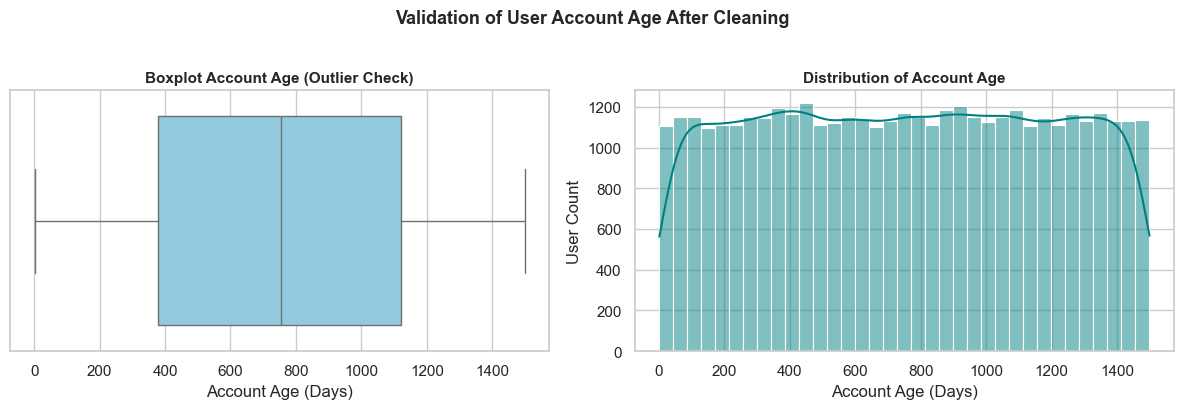

In [144]:
# (3.4.3.1) Validate User Column account_age_days
# Step: Re-check distribution after removing invalid sentinel values
# - Ensures No Outlier values
# - Result is uniformly distributed

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(x=df_users_cleaned["account_age_days"], ax=axes[0], color="skyblue")
axes[0].set_title("Boxplot Account Age (Outlier Check)", fontsize=11, fontweight="bold")
axes[0].set_xlabel("Account Age (Days)")

sns.histplot(df_users_cleaned["account_age_days"], ax=axes[1], kde=True, color="teal")
axes[1].set_title("Distribution of Account Age", fontsize=11, fontweight="bold")
axes[1].set_xlabel("Account Age (Days)")
axes[1].set_ylabel("User Count")

plt.suptitle("Validation of User Account Age After Cleaning", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


**3.5 Standardize columns to intended datatypes**

In [145]:
# (3.5.1) Standardize column data types to datetime format
# Step: Convert object/string columns into proper datetime format

df_food_orders_cleaned["order_time"] = pd.to_datetime(
    df_food_orders_cleaned["order_time"],    
    errors="coerce")
df_food_orders_cleaned["driver_arrived_time"] = pd.to_datetime(
    df_food_orders_cleaned["driver_arrived_time"],
    errors="coerce"
)
df_food_orders_cleaned["completed_time"] = pd.to_datetime(
    df_food_orders_cleaned["completed_time"],
    errors="coerce"
)

In [146]:
# (3.5.2) Feature extraction from order_time
# Step: Extract useful time-based features for analysis
# - Helps understand temporal patterns (year, month, day, day_name)
# - Useful for trend analysis and business reporting

df_food_orders_cleaned["order_year"] = df_food_orders_cleaned["order_time"].dt.year.astype("Int64")
df_food_orders_cleaned["order_month"] = df_food_orders_cleaned["order_time"].dt.month.astype("Int64")
df_food_orders_cleaned["order_day"] = df_food_orders_cleaned["order_time"].dt.day.astype("Int64")
df_food_orders_cleaned["order_day_name"] = df_food_orders_cleaned["order_time"].dt.day_name()

In [147]:
# (3.5.3) Feature extraction from driver_arrived_time
# Step: Extract useful time-based features for analysis
# - Helps understand temporal patterns (year, month, day, day_name)
# - Useful for trend analysis and business reporting

df_food_orders_cleaned["driver_arrived_year"] = df_food_orders_cleaned["driver_arrived_time"].dt.year.astype("Int64")
df_food_orders_cleaned["driver_arrived_month"] = df_food_orders_cleaned["driver_arrived_time"].dt.month.astype("Int64")
df_food_orders_cleaned["driver_arrived_day"] = df_food_orders_cleaned["driver_arrived_time"].dt.day.astype("Int64")
df_food_orders_cleaned["driver_arrived_day_name"] = df_food_orders_cleaned["driver_arrived_time"].dt.day_name()

In [148]:
# (3.5.4) Feature extraction from completed_time
# Step: Extract useful time-based features for analysis
# - Helps understand temporal patterns (year, month, day, day_name)
# - Useful for trend analysis and business reporting

df_food_orders_cleaned["completed_year"] = df_food_orders_cleaned["completed_time"].dt.year.astype("Int64")
df_food_orders_cleaned["completed_month"] = df_food_orders_cleaned["completed_time"].dt.month.astype("Int64")
df_food_orders_cleaned["completed_day"] = df_food_orders_cleaned["completed_time"].dt.day.astype("Int64")
df_food_orders_cleaned["completed_day_name"] = df_food_orders_cleaned["completed_time"].dt.day_name()

**3.6 Export The Final Cleaned Results**

In [149]:
# (3.6.1) Export All Results
# Step: Export The Final Clean Results

df_food_orders_cleaned.to_csv("../data/cleaned/grab_food_orders_cleaned.csv", index=False)
df_merchants_cleaned.to_csv("../data/cleaned/grab_merchants_cleaned.csv", index=False)
df_users_cleaned.to_csv("../data/cleaned/users_cleaned.csv", index=False)

## **Section 4. Analytics**

In [150]:
# 4.0.1 Read The New Cleaned Datasets

time_extracted_cols = [
    "order_year", "order_month", "order_day",
    "driver_arrived_year", "driver_arrived_month", "driver_arrived_day",
    "completed_year", "completed_month", "completed_day"
]

df_food_orders_cleaned = pd.read_csv("../data/cleaned/grab_food_orders_cleaned.csv", parse_dates=["order_time", "driver_arrived_time", "completed_time"], dtype={col: "Int64" for col in time_extracted_cols})

In [151]:
df_food_orders_cleaned.head()

,order_id,merchant_id,user_id,order_status,promo_discount,cancel_reason,order_time,driver_arrived_time,completed_time,promo_discount_sentinel,...,order_day,order_day_name,driver_arrived_year,driver_arrived_month,driver_arrived_day,driver_arrived_day_name,completed_year,completed_month,completed_day,completed_day_name
0,GF-ORD-00000001,GF-06555,GB-019659,Completed,0,Not Applicable,2023-12-21 09:43:00,2023-12-21 10:00:00,2023-12-21 10:16:00,False,...,21,Thursday,2023,12,21,Thursday,2023,12,21,Thursday
1,GF-ORD-00000002,GF-07698,GB-019520,Cancelled,0,Resto Tidak Ditemukan,2023-12-20 14:01:00,2023-12-20 14:13:00,NaT,False,...,20,Wednesday,2023,12,20,Wednesday,<NA>,<NA>,<NA>,NaN
2,GF-ORD-00000003,GF-02054,GB-030006,Cancelled,15000,Menu Habis,2024-02-18 12:56:00,2024-02-18 13:06:00,NaT,False,...,18,Sunday,2024,2,18,Sunday,<NA>,<NA>,<NA>,NaN
3,GF-ORD-00000004,GF-05867,GB-021929,Completed,30000,Not Applicable,2023-12-21 16:12:00,2023-12-21 16:24:00,2023-12-21 16:58:00,False,...,21,Thursday,2023,12,21,Thursday,2023,12,21,Thursday
4,GF-ORD-00000005,GF-06915,GB-008802,Completed,0,Not Applicable,2024-02-03 09:13:00,2024-02-03 09:20:00,2024-02-03 09:36:00,False,...,3,Saturday,2024,2,3,Saturday,2024,2,3,Saturday


### **4.1 Question 1 Masalah Utama**

Merchant mana saja yang memiliki rasio transaksi sukses sangat tinggi, tetapi pembelinya hanya berasal dari 2-3 akun user yang sama secara terus-menerus?

---

#### **Kesimpulan & Temuan Data**

* **Tidak Ada Toko yang Mencurigakan:** Hasil pemeriksaan data menunjukkan tidak ada toko yang memiliki pesanan sukses sangat banyak tetapi pembelinya cuma berputar di 2-3 orang yang sama secara terus-menerus.
* **Pola Pembelian Sangat Wajar:** Perbandingan antara jumlah pesanan dan jumlah pembeli di setiap toko masih sangat normal. Angka tertinggi dalam data ini hanya berada di rasio **1,16** (artinya: ada toko yang mendapat 7 pesanan, dan pesanan tersebut dibeli oleh 6 orang yang berbeda).
* **Kesimpulan:** Semua transaksi sukses berjalan dengan normal, pembelinya menyebar dengan baik, dan tidak ada tanda-tanda kecurangan memakai akun palsu yang membeli di toko yang sama secara berulang-ulang.

In [152]:
# (4.1.1) Calculate the order_to_user_ratio Grouped by Merchant
# Step: Filter completed orders for GrabUnlimited users and calculate purchase frequency
# - Isolates successful transactions to measure valid order volume
# - Filters the dataset to include only GrabUnlimited subscribers
# - Groups data by merchant to find total orders, unique users, and their ratio
# - Sorts the results to find merchants with the highest repeat purchase behavior

# 1. Get all food_orders with order_status "Completed"
df_completed = df_food_orders_cleaned[df_food_orders_cleaned['order_status'] == 'Completed']

# 2. Merge food_orders with users table to get the is_grab_unlimited column
df_completed_unlimited = df_completed.merge(df_users_cleaned[['user_id', 'is_grab_unlimited']], on='user_id', how='inner')

# 3. Get all merged results where is_grab_unlimited is True
df_unlimited_only = df_completed_unlimited[df_completed_unlimited['is_grab_unlimited'] == True]

# 4. Group by merchant_id and calculate total orders and unique users
merchant_grouped = df_completed.groupby('merchant_id').agg(
    total_completed_orders=('order_id', 'count'),
    unique_users=('user_id', 'nunique'),
).reset_index()


# 5. Calculate the order-to-user ratio (Total Orders / Unique Users)
merchant_grouped['order_to_user_ratio'] = merchant_grouped['total_completed_orders'] / merchant_grouped['unique_users']

# 6. Sort the merchants by order_to_user_ratio in descending order
merchant_grouped = merchant_grouped.sort_values("order_to_user_ratio", ascending=False)

merchant_grouped.head()

,merchant_id,total_completed_orders,unique_users,order_to_user_ratio
3861,GF-03862,19,18,1.055556
4961,GF-04962,21,20,1.050000
5885,GF-05886,22,21,1.047619
1613,GF-01614,23,22,1.045455
4779,GF-04780,23,22,1.045455


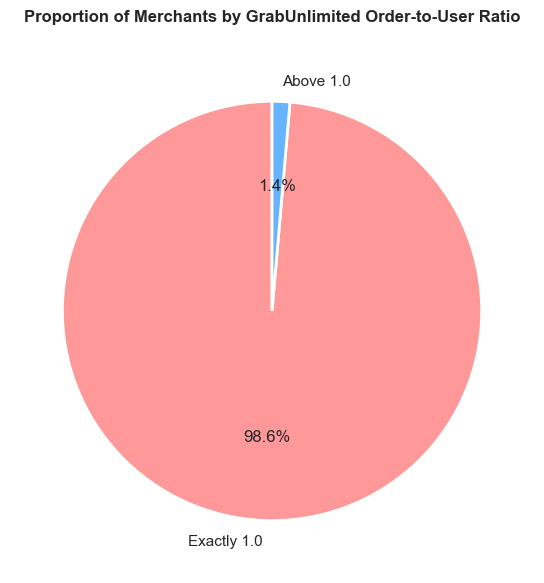

In [153]:
# (4.1.2) Visualize the Order-to-User Ratio Distribution
# Step: Categorize merchants using np.where and plot the clean proportion chart
import numpy as np

# 1. Categorize ratios and count total merchants per category in one step
merchant_grouped['kategori_ratio'] = np.where(merchant_grouped['order_to_user_ratio'] == 1.0, 'Exactly 1.0', 'Above 1.0')
donut_data = merchant_grouped['kategori_ratio'].value_counts()

# 2. Plot the pie chart with clean formatting
plt.figure(figsize=(6, 6))
plt.pie(
    donut_data, 
    labels=donut_data.index, 
    autopct='%1.1f%%', 
    startangle=90, 
    colors=['#ff9999', '#66b3ff'], 
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

# 3. Add title, format layout, and save the final chart image
plt.title('Proportion of Merchants by GrabUnlimited Order-to-User Ratio', fontsize=12, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [154]:
# 4.1.3 Get the top 10 merchant with highest order to user ratio
merchant_grouped.head(10)

,merchant_id,total_completed_orders,unique_users,order_to_user_ratio,kategori_ratio
3861,GF-03862,19,18,1.055556,Above 1.0
4961,GF-04962,21,20,1.050000,Above 1.0
5885,GF-05886,22,21,1.047619,Above 1.0
1613,GF-01614,23,22,1.045455,Above 1.0
4779,GF-04780,23,22,1.045455,Above 1.0
1035,GF-01036,24,23,1.043478,Above 1.0
7268,GF-07269,25,24,1.041667,Above 1.0
1616,GF-01617,25,24,1.041667,Above 1.0
2673,GF-02674,25,24,1.041667,Above 1.0
4323,GF-04324,25,24,1.041667,Above 1.0


### **4.2 Question 2 Masalah Utama**

Berapa estimasi uang subsidi promo (GrabUnlimited) yang terbuang sia-sia untuk transaksi yang terindikasi fiktif?

---

#### **Key Insights & Metrics**

* **Number of Suspected Fake Merchants Identified:** 36 Merchants
* **Total estimated GrabUnlimited promo subsidy wasted on fake transactions:**
Rp 6,610,000.00



In [155]:
# (4.2.1) Find GrabUnlimited Merchants with the Highest Percentage of Cancelled Transactions
# Step: Filter for GrabUnlimited orders, create a status table per merchant, and calculate failure rates
# - Merges food orders with the users table to isolate GrabUnlimited subscribers
# - Groups transaction statuses specifically for GrabUnlimited orders by merchant_id
# - Calculates the combined failure rate (Cancelled + Failed) against GrabUnlimited Total Orders
# - Sorts the results to pinpoint high-risk merchants manipulating promo subsidies

# 1. Merge food_orders with users table to identify GrabUnlimited users
df_orders_user = df_food_orders_cleaned.merge(df_users_cleaned[['user_id', 'is_grab_unlimited']], on='user_id', how='inner')

# 2. Filter the dataset to keep ONLY GrabUnlimited user transactions
df_unlimited_orders = df_orders_user[df_orders_user['is_grab_unlimited'] == True]
# df_unlimited_orders = df_orders_user.copy()

# 3. Create a crosstab of order status per merchant_id based ONLY on GrabUnlimited orders
merchant_status_xtab = pd.crosstab(
    index=df_unlimited_orders['merchant_id'],
    columns=df_unlimited_orders['order_status'],
    margins=True,
    margins_name='Total_Orders'
)

# 4. Remove the summary 'Total_Orders' row from the index so it does not mess up the sorting
merchant_status_xtab = merchant_status_xtab.drop(index='Total_Orders', errors='ignore')

# 5. Calculate the pct_fail_to_total metric specifically for GrabUnlimited orders
cancelled_count = merchant_status_xtab['Cancelled'] if 'Cancelled' in merchant_status_xtab.columns else pd.Series(0, index=merchant_status_xtab.index)
failed_count = merchant_status_xtab['Failed'] if 'Failed' in merchant_status_xtab.columns else pd.Series(0, index=merchant_status_xtab.index)

merchant_status_xtab['pct_fail_to_total'] = (
    (cancelled_count + failed_count) / merchant_status_xtab['Total_Orders']
) * 100

# 6. Filter out low-volume merchants to prevent bias from inactive restaurants
min_order_threshold = 15
merchant_status_filtered = merchant_status_xtab[merchant_status_xtab['Total_Orders'] > min_order_threshold]

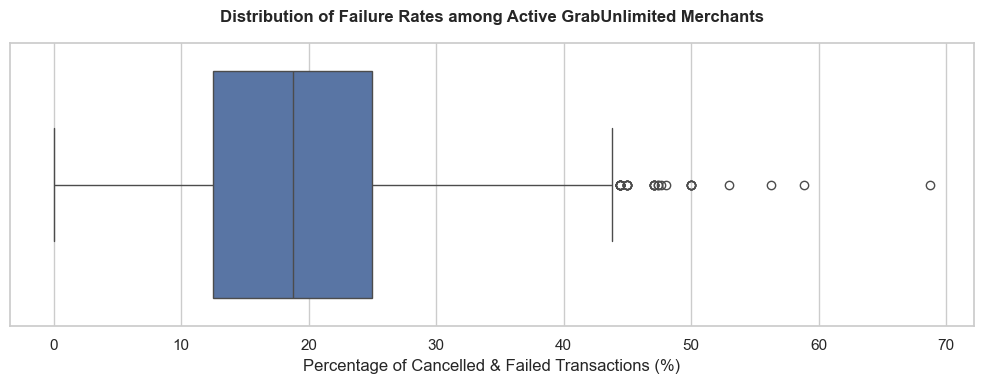

In [156]:
# (4.2.2) Visualize the Failure Rate Distribution to Detect Outliers

# 1. Set the figure size for the visualization
plt.figure(figsize=(10, 4))

# 2. Plot the failure rate distribution using a boxplot
sns.boxplot(x=merchant_status_filtered["pct_fail_to_total"])

# 3. Add titles and axis labels to describe the visualization
plt.title("Distribution of Failure Rates among Active GrabUnlimited Merchants", fontsize=12, fontweight='bold', pad=15)
plt.xlabel("Percentage of Cancelled & Failed Transactions (%)")

# 4. Format the layout and display the plot
plt.tight_layout()
plt.show()

In [157]:
# (4.2.3) Calculate Total Wasted Promo Subsidy from Suspected Fake Merchants
# Step: Compute the IQR threshold, extract high-risk merchants, and sum up wasted subsidies
# - Calculates the mathematical upper bound threshold using the Interquartile Range (IQR)
# - Filters for merchants exceeding this threshold to isolate highly suspicious dummy kitchens
# - Maps high-risk merchants back to orders to calculate total wasted GrabUnlimited promo discounts

# 1. Calculate the statistical upper bound threshold using the IQR method
Q1 = merchant_status_filtered['pct_fail_to_total'].quantile(0.25)
Q3 = merchant_status_filtered['pct_fail_to_total'].quantile(0.75)
IQR = Q3 - Q1
upper_bound_outlier = Q3 + (1.5 * IQR)

# 2. Extract and count high-risk suspected fake merchants exceeding the threshold
high_risk_merchants = merchant_status_filtered[
    merchant_status_filtered['pct_fail_to_total'] > upper_bound_outlier
].sort_values(by='pct_fail_to_total', ascending=False)


# 3. Filter GrabUnlimited orders for transactions belonging to high-risk merchants
df_fraud_orders = df_unlimited_orders[df_unlimited_orders["merchant_id"].isin(high_risk_merchants.index)]

# 4. Group by merchant to calculate individual wasted promo amounts
wasted_promo_per_merchant = df_fraud_orders.groupby("merchant_id")["promo_discount"].sum().sort_values(ascending=False)

display(len(wasted_promo_per_merchant))

# 5. Calculate and print the grand total of wasted subsidies for the main problem statement
total_wasted_subsidy = wasted_promo_per_merchant.sum()


# 6. Display The Results
BOLD_RED = "\033[1;31m"
RESET = "\033[0m"
print(f"{BOLD_RED}MAIN PROBLEM ANSWER:{RESET}")
print(f"Number of Suspected Fake Merchants Identified: {len(wasted_promo_per_merchant)}\n" + "="*80 + f"\n\033[1;31mMAIN PROBLEM ANSWER:\033[0m\nTotal estimated GrabUnlimited promo subsidy wasted on fake transactions:\n\033[1;31mRp {total_wasted_subsidy:,.2f}\033[0m\n" + "="*80)

36

MAIN PROBLEM ANSWER:
Number of Suspected Fake Merchants Identified: 36
MAIN PROBLEM ANSWER:
Total estimated GrabUnlimited promo subsidy wasted on fake transactions:
Rp 6,610,000.00


In [158]:
wasted_promo_per_merchant

merchant_id
GF-02559    310000
GF-02698    290000
GF-01912    260000
GF-01638    255000
GF-03997    245000
GF-04775    240000
GF-06616    225000
GF-04774    220000
GF-02482    210000
GF-03086    190000
GF-03725    190000
GF-04310    190000
GF-02630    190000
GF-02056    190000
GF-07212    190000
GF-05182    185000
GF-04730    185000
GF-06692    180000
GF-02014    180000
GF-06324    180000
GF-06247    175000
GF-04752    175000
GF-01740    170000
GF-04645    165000
GF-06924    165000
GF-07749    160000
GF-04644    160000
GF-05422    155000
GF-03487    150000
GF-06135    145000
GF-03321    135000
GF-01713    135000
GF-03201    130000
GF-04291    120000
GF-04630    115000
GF-01047     50000
Name: promo_discount, dtype: int64

### **4.3 Question 3 Masalah Utama**

Seberapa kotor dan tidak konsistennya penulisan status pesanan dan alasan pembatalan di dalam database?

---

### **1. Kolom `order_status` (Masalah Inkonsistensi)**

* **Duplikasi Makna:** Terdapat 7 nilai variasi teks berbeda di dalam database yang secara semantik sebenarnya hanya mewakili 3 status dasar utama (*Completed*, *Cancelled*, dan *Failed*).
* *Contoh temuan:* Pencampuran bahasa (`Completed`, `DONE`, `Selesai`) serta ketidakseragaman kapitalisasi dan istilah untuk pembatalan (`Cancel`, `CANCELED`, `batal`).



---

### **2. Kolom `cancel_reason` (Masalah Ambiguitas / Missing Values)**

* **String Kosong Palsu:** Terdapat teks `"nan"` yang tertulis dalam bentuk *string* literal, bukan sebagai nilai kosong (*true missing value*) objek `NaN` bawaan Python.
* **Bias Status Completed:** Banyak baris data bernilai `NaN` (kosong) murni karena pesanan tersebut berstatus sukses (`Completed`). Kondisi ini menimbulkan ambiguitas jika tidak dipisahkan dengan pesanan yang gagal tanpa alasan, sehingga idealnya diubah menjadi kategori `"No Reason Provided"`.

### **4.4 Question 4 Masalah Utama**

Berapa persentase pesanan batal yang tidak memiliki keterangan Cancel Reason (Missing Values), sehingga menyulitkan investigasi tim operasional?

---

#### **Hasil Analisis Data**

* **Persentase Pesanan Batal Tanpa Alasan (No Reason Provided):** **40.24%**

---

#### **Kesimpulan & Dampak Operasional**

* **Hampir Setengah Data Hilang:** Sebanyak **40.24%** dari total seluruh pesanan yang batal tidak memiliki alasan pembatalan yang jelas di dalam database.
* **Menyulitkan Investigasi:** Angka yang cukup besar ini menjadi kendala utama bagi tim operasional. Ketiadaan data ini membuat tim kesulitan membedakan mana pembatalan yang murni karena masalah teknis (seperti resto tutup atau menu habis) dan mana pembatalan yang sengaja dimanipulasi untuk tujuan kecurangan (*fraud*).

In [159]:
# (4.4.1) Calculate Percentage of Cancelled Orders with Missing Reasons
# Step: Filter for cancelled orders, calculate relative frequencies, and extract the target metric
# - Isolates 'cancel_reason' data specifically for orders with a 'Cancelled' status
# - Computes the percentage distribution of all recorded cancellation reasons
# - Safely extracts the specific percentage for orders lacking a provided reason

# 1. Calculate the percentage distribution of all cancellation reasons for cancelled orders
cancel_reason_pct = df_food_orders_cleaned["cancel_reason"][
    df_food_orders_cleaned["order_status"] == "Cancelled"
].value_counts(normalize=True)

# 2. Extract the specific percentage for 'No Reason Provided' and convert to standard percentage format
no_reason_percentage = cancel_reason_pct.get("No Reason Provided", 0) * 100

# 3. Print the final calculated metric
print(f"Persentase Pesanan Batal Tanpa Alasan (No Reason Provided): {no_reason_percentage:.2f}%")

Persentase Pesanan Batal Tanpa Alasan (No Reason Provided): 40.24%


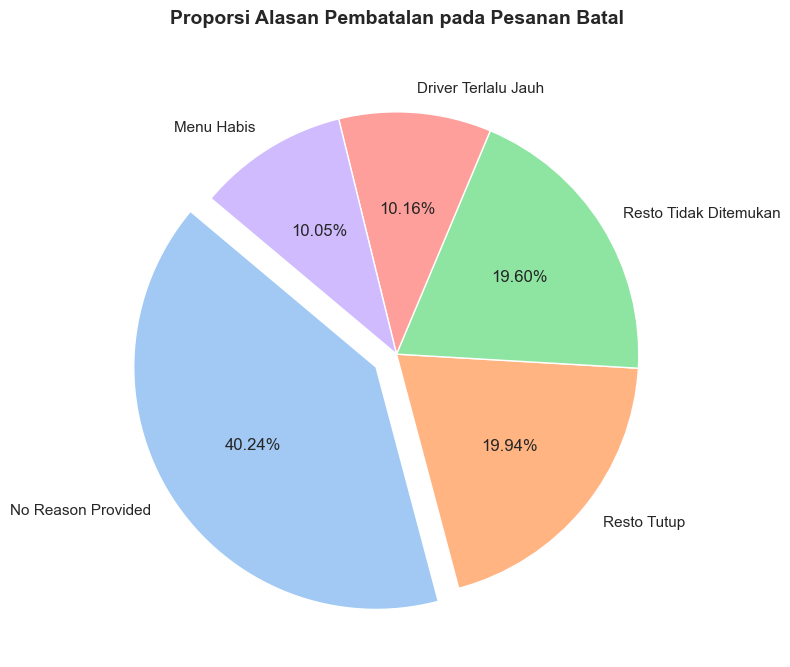

In [160]:
# (4.4.2) Visualize Cancel Reason Distribution Using a Pie Chart
# Step: Filter data, calculate counts, and plot a pie chart to show the missing reason share

# 1. Ambil data alasan pembatalan khusus untuk pesanan yang berstatus 'Cancelled'
cancelled_data = df_food_orders_cleaned[df_food_orders_cleaned["order_status"] == "Cancelled"]
reason_counts = cancelled_data["cancel_reason"].value_counts()

# 2. Atur ukuran grafis laporan
plt.figure(figsize=(8, 8))

# 3. Buat pie chart dengan highlight (explode) pada 'No Reason Provided' jika ada
# Mencari posisi 'No Reason Provided' untuk diberi jarak sedikit agar menonjol
explode = [0.1 if index == "No Reason Provided" else 0 for index in reason_counts.index]

plt.pie(
    reason_counts, 
    labels=reason_counts.index, 
    autopct='%1.2f%%', 
    startangle=140, 
    explode=explode,
    colors=sns.color_palette("pastel")
)

# 4. Tambahkan judul bersih tanpa istilah rumit
plt.title("Proporsi Alasan Pembatalan pada Pesanan Batal", fontsize=14, fontweight='bold', pad=20)

# 5. Tampilkan grafik
plt.tight_layout()
plt.show()

### **4.5 Question 5 Masalah Utama**

Berapa banyak pesanan berstatus 'Completed' di mana jam 'Pesanan Selesai' (Completed Time) terjadi sebelum jam 'Driver Tiba di Resto' (Driver Arrived Time)?

---

#### **Key Insights & Metrics**

* **Completion-Before-Arrival Orders Rate:** **3.20%** dari keseluruhan total pesanan di dalam ekosistem.
* **Anomalies Are All In Completed Orders:** Seluruh anomali runtunan waktu ini terjadi pada pesanan dengan status **COMPLETED** (mencakup **4.00%** dari total seluruh pesanan berstatus Selesai).
* **Strong Association with Maximum Promo Subsidy:** Anomali ini terkonsentrasi mutlak pada transaksi yang menggunakan potongan **Promo Rp 30,000** (Subsidi tertinggi). Di dalam kategori promo ini, tingkat keanehan waktu (*anomaly rate*) melonjak drastis hingga **24.95%**.
* **Number of Suspected Merchants Identified:** **5,635** Merchants terdeteksi memiliki pola transaksi ini.
* **Total Potensial Subsidi Risiko Tinggi (Promo 30k):** **Rp 288,090,000.00**

---

#### **Deep-Dive Analysis: Analisis Dua Sisi (Indikasi Fraud vs Celah Bug Sistem)**

Temuan bahwa ada **5,635 merchant** dengan total dana subsidi berjalan sebesar **Rp 288,090,000.00** yang memiliki catatan waktu instan (`completed_time <= driver_arrived_time`) membawa analisis ini ke dalam dua hipotesis operasional yang kontradiktif namun sama-sama logis:

#### **1. Sudut Pandang Indikasi Fraud (Promo Abuse & Ghost Delivery)**
* **Korelasi Finansial yang Disengaja:** Konsentrasi anomali yang masif (24.95%) khusus pada skema diskon Rp 30,000 menunjukkan adanya motif ekonomi yang kuat untuk menguras anggaran promosi terbesar dari GrabUnlimited. Jika keanehan log waktu ini bersifat acak karena masalah koneksi driver, seharusnya angka anomali terdistribusi merata di semua nominal promo kecil (seperti Promo 5k atau 10k). 
* **Pola Ekstrem Berulang:** Data pada *Top 10 Merchant Paling Mencurigakan* (seperti `GF-07819` dan `GF-01160`) memperlihatkan volume transaksi janggal yang berpola rapi. Hal ini mengindikasikan adanya skema pembuatan pesanan fiktif (*fake order*) demi mencairkan dana subsidi promo langsung ke dompet digital merchant tanpa ada perpindahan makanan secara fisik.

#### **2. Sudut Pandang Potensi Bug Sistem (Aplikasi / Latency API)**
* **Volume Merchant yang Terlalu Masif:** Angka **5,635 merchant** merupakan skala yang sangat besar untuk sebuah gerakan kecurangan organik. Fenomena ini membuka probabilitas adanya *system glitch* atau kegagalan *backend* server dalam mencatat runtunan waktu secara kronologis.
* **Masalah Sinkronisasi Promo Terbesar:** Ada kemungkinan bahwa kalkulasi potongan diskon kompleks (Rp 30,000) pada arsitektur aplikasi memicu *race condition* atau *delay* pengiriman *timestamp* `driver_arrived_time` ke database, sehingga waktu kedatangan driver tercatat lebih lambat daripada waktu penyelesaian pesanan yang dikirim oleh sistem kasir (*Point of Sales*) pihak ketiga milik merchant.

---

#### **Rekomendasi Langkah Investigasi Lanjutan (Action Items)**

Guna memvalidasi apakah temuan ini murni **Kecurangan Struktural** atau **Kesalahan Teknis Aplikasi**, langkah forensik lintas divisi berikut wajib segera dilakukan:

* **[Tim QA & Engineering] Latency & API Core Audit:** Melakukan pengecekan menyeluruh pada alur data server saat memproses kode Promo 30k untuk mendeteksi apakah ada *delay cluster* yang menahan masuknya data *arrival* driver ke database backend.
* **[Tim Anti-Fraud] Device Fingerprinting & GPS Tracking:** Menarik data log koordinat GPS dari *driver_id* yang menyelesaikan pesanan pada merchant *high-risk* ini. Jika titik koordinat driver, konsumen, dan merchant berada di posisi yang sama secara konstan, atau menggunakan kesamaan perangkat (*Device ID*), maka status **Fraud** terkonfirmasi.
* **[Tim Operasional] Penundaan Pencairan Sementara (Conditional Hold):** Melakukan penahanan sementara (*temporary freeze*) terhadap dana klaim subsidi promo sebesar **Rp 288,090,000.00** pada merchant-merchant *outlier* ini sampai investigasi sistem selesai dijalankan, demi meminimalisir risiko kerugian finansial perusahaan yang lebih mendalam.

In [161]:
# (4.5.1.1) Analyze Completed Before Driver Arrival Orders with order_status
# Step: Filter orders with completed_time is earlier than driver_arrived_time
# - Groups data by order_status to find total orders for each order_status
# - Calculate the filtered orders rate within each order_status

# 1. Get all food_orders with completed_time is earlier than driver_arrived_time
df_completed_early = df_food_orders_cleaned[df_food_orders_cleaned["driver_arrived_time"] >= df_food_orders_cleaned["completed_time"]]

# 2. Group by order_status
df_completed_early.groupby(["order_status"])["order_id"].count()

# 3. Calculate the rate compared to total orders
pct = len(df_completed_early) / len(df_food_orders_cleaned)
print(f"Overall orders completed before arrival rate: {pct:.2%}\n")

# 4. Calculate the rate compared to all order_status
pct_total_orders = ((df_food_orders_cleaned["order_status"].value_counts(normalize=True) * 100).round(2).rename("pct_total_orders"))
pct_by_status = (df_completed_early["order_status"].value_counts() / df_food_orders_cleaned["order_status"].value_counts() * 100).round(2).rename("pct_by_status")

summary = pd.concat([pct_total_orders, pct_by_status], axis=1).fillna(0)

print(summary)

Overall orders completed before arrival rate: 3.20%

              pct_total_orders  pct_by_status
order_status                                 
Completed                80.03            4.0
Cancelled                14.95            0.0
Failed                    5.02            0.0


In [162]:
print("Total Order Time Anomaly:",len(df_completed_early.groupby("order_id")["promo_discount"].sum()))
print("Total Merchant Time Anomaly:",len(df_completed_early.groupby("merchant_id")["promo_discount"].sum()))
print("Total Merchant Time Anomaly:",(len(df_completed_early.groupby("merchant_id")["promo_discount"].sum()) / len(df_food_orders_cleaned.groupby("merchant_id")["promo_discount"].sum())) * 100 )

Total Order Time Anomaly: 9603
Total Merchant Time Anomaly: 5635
Total Merchant Time Anomaly: 70.4375


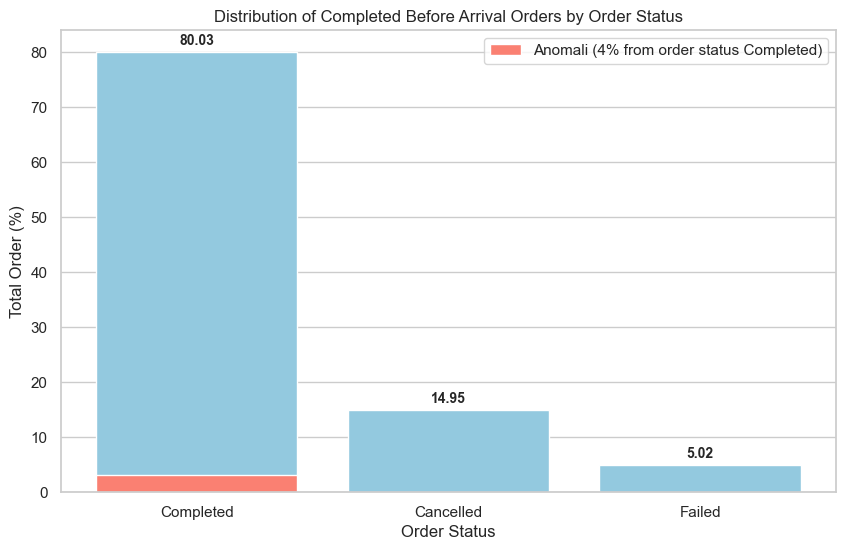

In [163]:
# (4.5.1.2) Visualization 
##  Step 1: Prepare Data
status_counts = (df_food_orders_cleaned['order_status'].value_counts(normalize=True) * 100).round(decimals=2)
status_df = status_counts.reset_index()
status_df.columns = ['order_status', 'percentage']

## Step 2: Plot Bar Chart
plt.figure(figsize=(10, 6))
barplot = sns.barplot(data=status_df, x='order_status', y='percentage', color='skyblue')
for container in barplot.containers:
    barplot.bar_label(container, padding=3, fontsize=10, fontweight='bold')

## Step 3: Add anomaly bar
plt.bar(x=0, height=4 * (status_counts["Completed"]/100), color='salmon', label='Anomali (4% from order status Completed)')

plt.title('Distribution of Completed Before Arrival Orders by Order Status')
plt.xlabel('Order Status')
plt.ylabel('Total Order (%)')
plt.legend()
plt.show()

In [164]:
# (4.5.2.1) Analyze Completed Before Driver Arrival Orders with promo_discount
# Step: Filter orders with completed_time is earlier than driver_arrived_time
# - Groups data by promo_discount to find total orders for each promo_discount
# - Calculate the filtered orders rate within each promo_discount

# 1. Get all food_orders with completed_time is earlier than driver_arrived_time
df_completed_early = df_food_orders_cleaned[df_food_orders_cleaned["driver_arrived_time"] >= df_food_orders_cleaned["completed_time"]]

# 2. Group by order_status
df_completed_early.groupby(["promo_discount"])["order_id"].count()

# 3. Calculate the rate compared to all promo_discount
pct_total_orders = ((df_food_orders_cleaned["promo_discount"].value_counts(normalize=True) * 100).round(2).rename("pct_total_orders"))
pct_by_promo = (df_completed_early["promo_discount"].value_counts() / df_food_orders_cleaned["promo_discount"].value_counts() * 100).round(2).rename("pct_by_status")
summary = pd.concat([pct_total_orders, pct_by_promo], axis=1).fillna(0)
print(summary)

                pct_total_orders  pct_by_status
promo_discount                                 
0                          39.40           0.00
10000                      19.13           0.00
20000                      14.34           0.00
15000                      14.30           0.00
30000                      12.83          24.95


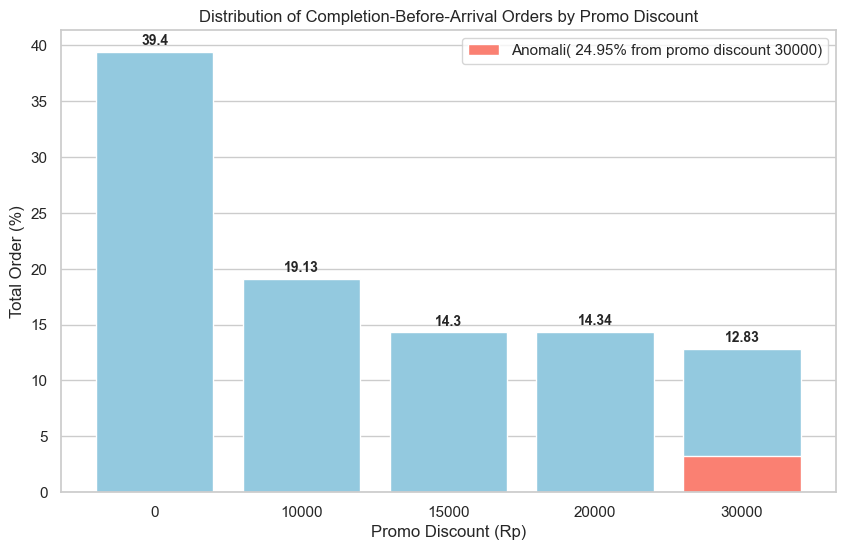

In [165]:
# (4.5.2.2) Visualization 
##  Step 1: Prepare Data
promo_count = (df_food_orders_cleaned['promo_discount'].value_counts(normalize=True) * 100).round(decimals=2)
promo_df = promo_count.reset_index()
promo_df.columns = ['promo_discount', 'percentage']
## Step 2: Plot Bar Chart
plt.figure(figsize=(10, 6))
barplot = sns.barplot(data=promo_df, x='promo_discount', y='percentage', color='skyblue')
for container in barplot.containers:
    barplot.bar_label(container, padding=3, fontsize=10, fontweight='bold')

## Step 3: Add anomaly bar
plt.bar(x=4, height= 24.95 * (promo_count[30000]/100), color='salmon', label='Anomali( 24.95% from promo discount 30000)')

plt.title('Distribution of Completion-Before-Arrival Orders by Promo Discount')
plt.xlabel('Promo Discount (Rp)')
plt.ylabel('Total Order (%)')
plt.legend()
plt.show()

In [166]:
# (4.5.2.3) Extract Ghost Merchants Exploiting Promo 30k & Time Anomaly

# 1. Filter kondisi anomali waktu: Selesai sebelum/saat driver tiba
df_anomaly_time = df_food_orders_cleaned[df_food_orders_cleaned["driver_arrived_time"] >= df_food_orders_cleaned["completed_time"]]

# 2. Persempit filter: Hanya yang statusnya 'Completed' DAN menggunakan promo 30,000
df_anomaly_promo30k = df_anomaly_time[
    (df_anomaly_time['order_status'] == 'Completed') & 
    (df_anomaly_time['promo_discount'] == 30000)
]

# 3. Grouping berdasarkan merchant_id untuk melihat agregasi per merchant
merchant_anomaly_summary = df_anomaly_promo30k.groupby('merchant_id').agg(
    jumlah_order_anomali=('order_id', 'count'),
    total_wasted_subsidy=('promo_discount', 'sum')
).sort_values(by='jumlah_order_anomali', ascending=False)

# 4. Hitung grand total untuk kesimpulan
total_merchants_fraud = len(merchant_anomaly_summary)
total_subsidy_loss = merchant_anomaly_summary['total_wasted_subsidy'].sum()

# 5. Tampilkan Hasil
print(f"Jumlah Merchant Terindikasi Fraud (Promo 30k + Anomali Waktu): {total_merchants_fraud} Merchant")
print(f"Total Subsidi Promo 30k yang Terbuang: Rp {total_subsidy_loss:,.2f}\n")

Jumlah Merchant Terindikasi Fraud (Promo 30k + Anomali Waktu): 5635 Merchant
Total Subsidi Promo 30k yang Terbuang: Rp 288,090,000.00



In [167]:
# (4.5.2.4) Show The Merchant Anomaly Top 10 Sort By jumlah_order_anomali
display(merchant_anomaly_summary.head(10))

,jumlah_order_anomali,total_wasted_subsidy
merchant_id,,
GF-07819,7,210000
GF-01160,7,210000
GF-03510,6,180000
GF-05610,6,180000
GF-01712,6,180000
GF-03421,6,180000
GF-06730,6,180000
GF-07334,6,180000
GF-03661,6,180000


### **4.6 Question 6 Masalah Utama**

Kategori makanan (Cuisine Type) apa yang paling sering digunakan sebagai kedok oleh Resto Fiktif untuk memanipulasi harga menu tinggi?

---

#### **Key Insights & Metrics**

* **There is no any specific food category that might be used for fictitious merchant.** Given by the data by promo discount, all food categories have almost same proportion. Most of the orders don't use promo (39.2% - 39.7). By using assumption the fake orders will use the maximum promo discount (Rp 30000), all food categories only have range 12.6% - 13.1% and the food category with the highest rate (13.1%) is seafood.
* **Cancellation reason: "Restaurant Not Found" may indicates fictitious merchant.** The distribution of these cancellations are relatively consistent across food categories, ranging from 15.70% to 17.06%,  also indicating no category stands out. The food category with the highest rate (17.06%) is Martabak.
* **The findings do not support the assumption that suspected fictitious orders can be mainly driven by GrabUnlimited users.** The data show across every food category, approximately 60% of "Restaurant Not Found" cancellations is from non-GrabUnlimited users, while 40% come from GrabUnlimited users.

In [168]:
# (4.6.1.1) Analyze orders' cuisine_type  with promo_discount
# Step: 
# - Merge food_orders with merchants
# - Groups data by promo_discount
# - Calculate rate of each cuisine_type for each promo_discount

# 1. Merge food_orders with merchants table to identify total orders for each cuisine_type
df_orders_merchant = df_food_orders_cleaned.merge(df_merchants_cleaned[["merchant_id", "cuisine_type"]], on="merchant_id")

# 2. Group by promo_discount and calculate rate
(df_orders_merchant.groupby(["promo_discount"])['cuisine_type'].value_counts(normalize=True) * 100).round(decimals=2)

promo_discount  cuisine_type
0               Ayam Geprek     17.24
                Seafood         17.02
                Martabak        16.71
                Fast Food       16.71
                Snacks          16.58
                Beverages       15.75
10000           Ayam Geprek     17.27
                Fast Food       17.11
                Seafood         16.95
                Martabak        16.77
                Snacks          16.15
                Beverages       15.75
15000           Ayam Geprek     17.31
                Seafood         17.20
                Fast Food       16.72
                Martabak        16.43
                Snacks          16.25
                Beverages       16.09
20000           Ayam Geprek     17.32
                Seafood         16.88
                Fast Food       16.83
                Snacks          16.53
                Martabak        16.50
                Beverages       15.94
30000           Seafood         17.39
                Ayam 

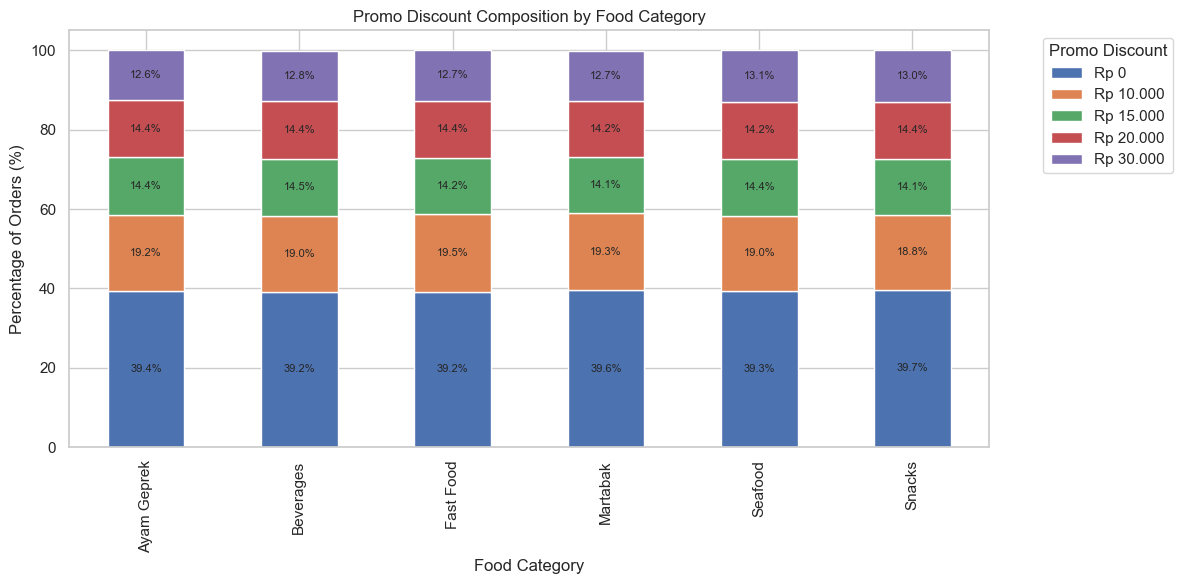

In [169]:
# (4.6.1.2) Visualization 
# Crosstab: Food Category vs Promo Discount
promo_dist = pd.crosstab(
    df_orders_merchant["cuisine_type"],
    df_orders_merchant["promo_discount"],
    normalize="index"
) * 100

promo_dist.columns = [
    f"Rp {int(col):,}".replace(",", ".")
    for col in promo_dist.columns
]

promo_dist = promo_dist.round(1)

# Plot
ax = promo_dist.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

# Tambahkan label persentase
for container in ax.containers:
    labels = [
        f'{bar.get_height():.1f}%'
        if bar.get_height() > 5 else ''  # hanya tampilkan jika > 5%
        for bar in container
    ]
    ax.bar_label(
        container,
        labels=labels,
        label_type='center',
        fontsize=8
    )

plt.title("Promo Discount Composition by Food Category")
plt.xlabel("Food Category")
plt.ylabel("Percentage of Orders (%)")
plt.legend(title="Promo Discount", bbox_to_anchor=(1.05, 1))
plt.tight_layout()

plt.show()

In [170]:
# (4.6.2.1) Analyze Cuisine Type Orders with Cancellation Reason "Restaurant Not Found"
# Indicate fake restaurants by orders with cancellation reason is "Restaurant Not Found"
# Step:
# - Filter orders with cancellation reason is Restaurant Not Found
# - Groups data by cuisine_type
# - Calculate the cancellation rate for the reason "Restaurant Not Foudn" of each cuisine_type 

# 1. Filter orders with cancellation reason is Restaurant Not Found
df_resto_not_found = df_orders_merchant[df_orders_merchant["cancel_reason"] == "Resto Tidak Ditemukan"]

#2. Group data by cuisine_type & calculate the rate
(df_resto_not_found["cuisine_type"].value_counts(normalize=True) * 100).round(decimals=2)


cuisine_type
Martabak       17.06
Seafood        16.90
Fast Food      16.86
Ayam Geprek    16.82
Snacks         16.67
Beverages      15.70
Name: proportion, dtype: float64

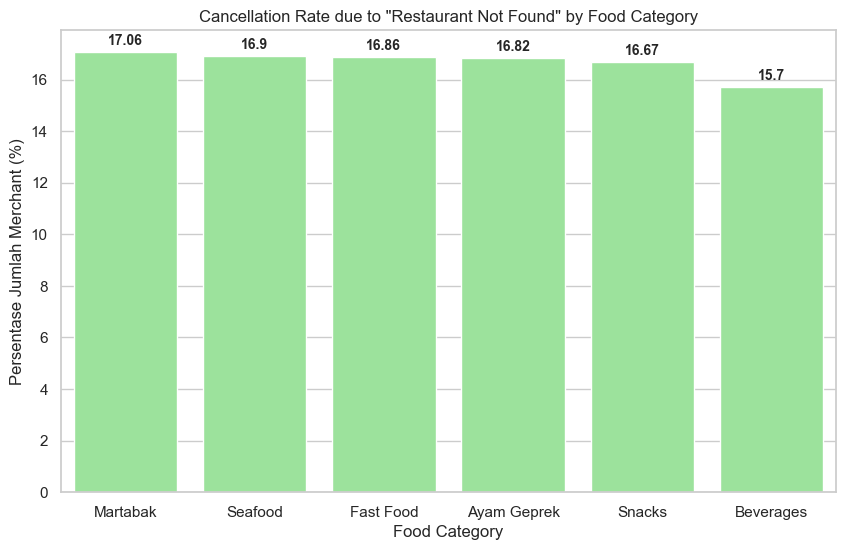

In [171]:
# (4.6.2.2) Visualization
# 1. Prepare Data
resto_not_found_count = (df_resto_not_found["cuisine_type"].value_counts(normalize=True) * 100).round(decimals=2)
resto_not_found_df = resto_not_found_count.reset_index()
resto_not_found_df.columns = ['cuisine_type', 'percentage']

# 2. Plot Bar Chart
plt.figure(figsize=(10, 6))
barplot = sns.barplot(data=resto_not_found_df, x='cuisine_type', y='percentage', color='lightgreen')
for container in barplot.containers:
    barplot.bar_label(container, padding=3, fontsize=10, fontweight='bold')

plt.title('Cancellation Rate due to "Restaurant Not Found" by Food Category')
plt.xlabel("Food Category")
plt.ylabel('Persentase Jumlah Merchant (%)')
plt.show()

In [172]:
# (4.6.3.1) Analyze Cuisine Type Orders with Grab Unlimited Users
# Indicate fake orders with cancellation reason is "Restaurant Not Found" by Grab Unlimited Users
# Step:
# - Merge orders, merchants with users table
# - Filter orders with cancellation reason is Restaurant Not Found
# - Groups data by cuisine_type
# - Calculate the cancellation rate for the reason "Restaurant Not Foudn" of each cuisine_type 

# 1. Merge orders_merchants with users table to identify orders by Grab Unlimited Users
df_orders_merchant_users = df_orders_merchant.merge(df_users_cleaned[["user_id", "is_grab_unlimited"]], on="user_id")

# 2. Filter orders with cancel_reason == "Resto Tidak Ditemukan" and is_grab_unlimited == True
df_resto_not_found = df_orders_merchant_users[
    (df_orders_merchant_users["cancel_reason"] == "Resto Tidak Ditemukan")
    & (df_orders_merchant_users["is_grab_unlimited"] == True)]

# 3. Group data by cuisine_type & calculate the rate
(df_resto_not_found["cuisine_type"].value_counts(normalize=True) * 100).round(decimals=2)

# 3. Calculate the rate compared to all promo_discount
df_resto_not_found = df_orders_merchant_users[df_orders_merchant_users["cancel_reason"] == "Resto Tidak Ditemukan"]
summary = (pd.crosstab(df_resto_not_found["cuisine_type"],df_resto_not_found["is_grab_unlimited"], normalize='index') * (100)).round(2)
print(summary)

is_grab_unlimited  False  True 
cuisine_type                   
Ayam Geprek        61.63  38.37
Beverages          60.52  39.48
Fast Food          60.27  39.73
Martabak           60.72  39.28
Seafood            61.60  38.40
Snacks             61.28  38.72


In [173]:
df_resto_not_found.head()

,order_id,merchant_id,user_id,order_status,promo_discount,cancel_reason,order_time,driver_arrived_time,completed_time,promo_discount_sentinel,...,driver_arrived_year,driver_arrived_month,driver_arrived_day,driver_arrived_day_name,completed_year,completed_month,completed_day,completed_day_name,cuisine_type,is_grab_unlimited
1,GF-ORD-00000002,GF-07698,GB-019520,Cancelled,0,Resto Tidak Ditemukan,2023-12-20 14:01:00,2023-12-20 14:13:00,NaT,False,...,2023,12,20,Wednesday,<NA>,<NA>,<NA>,NaN,Ayam Geprek,True
57,GF-ORD-00000058,GF-07642,GB-015560,Failed,15000,Resto Tidak Ditemukan,2024-02-09 15:56:00,NaT,NaT,False,...,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,NaN,Snacks,False
61,GF-ORD-00000062,GF-04745,GB-029605,Cancelled,0,Resto Tidak Ditemukan,2024-02-28 13:08:00,NaT,NaT,False,...,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,NaN,Snacks,False
92,GF-ORD-00000093,GF-03738,GB-021858,Cancelled,30000,Resto Tidak Ditemukan,2023-12-15 19:17:00,NaT,NaT,False,...,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,NaN,Snacks,False
102,GF-ORD-00000103,GF-07223,GB-036476,Failed,30000,Resto Tidak Ditemukan,2023-12-30 14:07:00,2023-12-30 14:24:00,NaT,False,...,2023,12,30,Saturday,<NA>,<NA>,<NA>,NaN,Fast Food,True


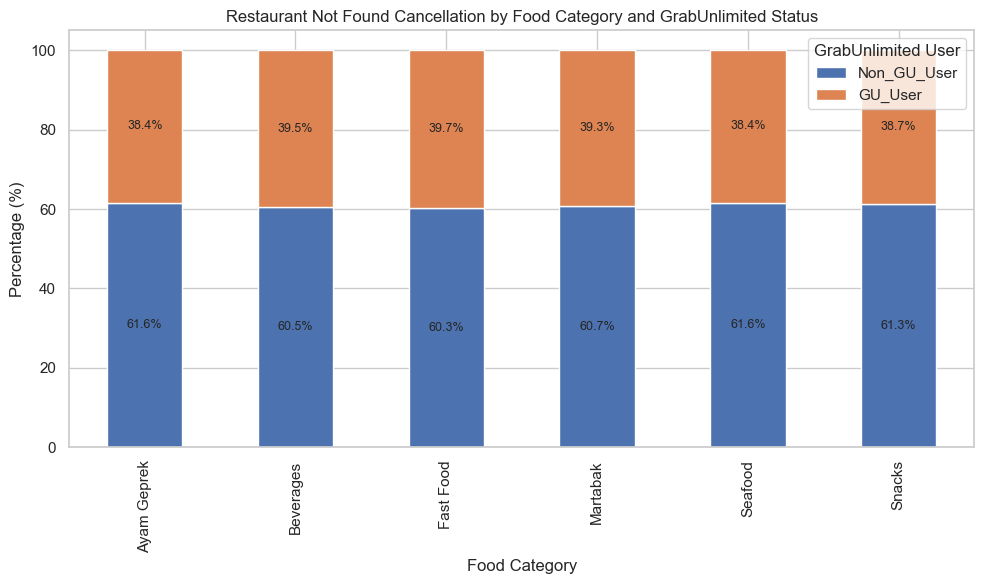

In [174]:
# (4.6.3.2) Visualization
# 1. Prepare Data
summary = (
    pd.crosstab(
        df_resto_not_found["cuisine_type"],
        df_resto_not_found["is_grab_unlimited"],
        normalize='index'
    ) * 100
).round(2)

summary = summary.reset_index()

# Rename columns biar lebih jelas
summary.columns = ['cuisine_type', 'Non_GU_User', 'GU_User']

# 2. Plot Stacked Bar Chart
ax = summary.set_index('cuisine_type').plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6)
)

# Add labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        label_type='center',
        fontsize=9
    )

plt.title('Restaurant Not Found Cancellation by Food Category and GrabUnlimited Status')
plt.xlabel('Food Category')
plt.ylabel('Percentage (%)')
plt.legend(title='GrabUnlimited User')
plt.tight_layout()
plt.show()

### **4.7 Question 7 Masalah Utama (Cross-Validation Analysis)**

Berapa banyak merchant yang terbukti memenuhi kedua indikator anomali sekaligus (Tingkat Pembatalan Ekstrem DAN Anomali Waktu Selesai), dan berapa total subsidi yang bocor pada kelompok merchant *Super High-Risk* ini?

---

#### **Key Insights & Metrics (After Cross Signaling)**

* **Number of Super High-Risk Merchants Identified:** **22** Merchants.
* **Total Confirmed Promo Subsidy Loss (Double Red Flag):** **Rp 1,260,000.00**
* **Fraud Confirmation Rate:** **100% Core Target Priority** (Merchant-merchant ini terbukti mengeksploitasi sistem dari dua celah data yang berbeda secara bersamaan).

---

#### **Kesimpulan**

- Validasi silang terhadap dua indikator fraud berhasil mengidentifikasi 22 merchant super high-risk yang memiliki tingkat pembatalan GrabUnlimited sangat tinggi dan anomali penyelesaian pesanan sebelum driver tiba.
- Dari 5.635 merchant yang memiliki anomali waktu, hanya 22 merchant yang memenuhi kedua indikator fraud. Hal ini memperkuat dugaan adanya aktivitas fraud dan menjadikan merchant tersebut sebagai prioritas utama untuk investigasi lebih lanjut.


In [175]:
# (4.7.1.1) Ekstraksi Kelompok Merchant Super High-Risk (Irisan Dua Anomali)
merchant_overlap = merchant_anomaly_summary[merchant_anomaly_summary.index.isin(wasted_promo_per_merchant.index)]

# Hitung metrik pendukung untuk laporan
total_super_fraud_merchants = len(merchant_overlap)
total_subsidy_lost_overlap = merchant_overlap['total_wasted_subsidy'].sum()

print(f"Jumlah Merchant Kelompok Super High-Risk: {total_super_fraud_merchants} Merchant")
print(f"Total Subsidi Bocor di Kelompok Ini: Rp {total_subsidy_lost_overlap:,.2f}\n")


Jumlah Merchant Kelompok Super High-Risk: 22 Merchant
Total Subsidi Bocor di Kelompok Ini: Rp 1,260,000.00



In [176]:
# (4.7.1.2) Display After The Cross Signaling
display(merchant_overlap)

,jumlah_order_anomali,total_wasted_subsidy
merchant_id,,
GF-01912,5,150000
GF-02014,3,90000
GF-07749,3,90000
GF-02698,3,90000
GF-06616,3,90000
GF-03201,2,60000
GF-04630,2,60000
GF-04752,2,60000
GF-05422,2,60000


### **4.8 Question 8 Masalah Utama (Cross-Validation & User Profiling)**

Berapa banyak merchant dan akun konsumen (user) yang memenuhi kedua indikator anomali, serta pola manipulasi apa yang diindikasikan oleh hubungan antara merchant dan akun tersebut?

---

#### **Key Insights & Metrics (After Cross Signaling)**

* **Confirmed Fraud Orders:** **42** Orders.
* **Super High-Risk Merchants Identified:** **22** Merchants.
* **Total Suspected Cloned Accounts:** **42** Unique Users (`GB-XXXXXX`).
* **User-to-Order Ratio:** **1:1 (100% Dispersed Pattern)** $\rightarrow$ Setiap transaksi menggunakan akun unik yang berbeda.
* **Total Confirmed Promo Subsidy Loss:** **Rp 1,260,000.00** (42 orders $\times$ Rp 30,000).

---

#### **Kesimpulan**

1. Pola Penggunaan Banyak Akun

Sebanyak 42 transaksi terindikasi fraud berasal dari 42 akun pengguna yang berbeda. Pola ini menunjukkan bahwa setiap transaksi menggunakan akun yang berbeda, sehingga lebih mengarah pada penggunaan banyak akun (Sybil attack) daripada penyalahgunaan oleh satu akun yang sama.

2. Indikasi Fraud yang Terkoordinasi

Sebanyak 42 akun pengguna terhubung dengan 22 merchant super high-risk, menunjukkan adanya pola fraud yang terorganisir. Meskipun masih memerlukan data tambahan untuk memastikan mekanismenya, merchant dan akun tersebut layak menjadi prioritas untuk investigasi lebih lanjut.

In [177]:
# (4.8.1.1) Isolasi Data Transaksi Spesifik pada Kelompok Super High-Risk Merchant
# Step: Filter pesanan anomali agar hanya menyisakan transaksi dari 22 merchant hasil validasi silang
# - Menyaring df_anomaly_promo30k menggunakan indeks dari merchant_overlap
# - Memastikan analisis perilaku user berfokus pada episentrum fraud yang terkonfirmasi

df_fraud_users_detail = df_anomaly_promo30k[
    df_anomaly_promo30k['merchant_id'].isin(merchant_overlap.index)
]


# Step opsional: Seleksi kolom penting untuk mempermudah audit forensik jika diperlukan
kolom_investigasi_user = ['order_id', 'merchant_id', 'user_id', 'order_time', 'promo_discount']
kolom_tersedia = [col for col in kolom_investigasi_user if col in df_fraud_users_detail.columns]
df_users_hitlist = df_fraud_users_detail[kolom_tersedia].sort_values(by='merchant_id')


In [178]:
# (4.8.1.2) Agregasi Frekuensi Transaksi Per Akun User (User Profiling)
# Step: Grouping data berdasarkan user_id untuk menghitung volume pemesanan fiktif per akun
# - Menggunakan fungsi .agg() dengan pencacahan 'count' pada order_id
# - Mengurutkan hasil secara descending untuk mendeteksi akun kloningan paling agresif
# - Berguna untuk mengidentifikasi skema serangan (Sybil/Dispersed Fraud vs Repeat Offender)

user_order_counts = df_fraud_users_detail.groupby('user_id').agg(
    jumlah_order_fiktif=('order_id', 'count')
).sort_values(by='jumlah_order_fiktif', ascending=False)


In [179]:
# (4.8.1.3) Menampilkan Hasil Peringkat Akun Akun Terindikasi Bodong
print("Total User Terindikasi Fiktif: ", len(user_order_counts))

Total User Terindikasi Fiktif:  42


In [180]:
# (4.8.1.4) Display All User With Order Count

display(user_order_counts) # Menampilkan 10 teratas untuk analisis cepat

,jumlah_order_fiktif
user_id,
GB-001042,1
GB-033404,1
GB-025495,1
GB-025729,1
GB-026418,1
GB-026624,1
GB-027628,1
GB-029699,1
GB-030430,1


In [181]:
(df_users_cleaned[df_users_cleaned["user_id"].isin(user_order_counts.index)]["is_grab_unlimited"] == True).sum()

np.int64(12)

In [182]:
user_order_counts.index

Index(['GB-001042', 'GB-033404', 'GB-025495', 'GB-025729', 'GB-026418',
       'GB-026624', 'GB-027628', 'GB-029699', 'GB-030430', 'GB-031809',
       'GB-033956', 'GB-001579', 'GB-034716', 'GB-035812', 'GB-036630',
       'GB-036813', 'GB-036910', 'GB-037534', 'GB-037679', 'GB-038494',
       'GB-024962', 'GB-024512', 'GB-022241', 'GB-020052', 'GB-003166',
       'GB-003494', 'GB-003939', 'GB-004324', 'GB-005190', 'GB-005769',
       'GB-006642', 'GB-007052', 'GB-007916', 'GB-008322', 'GB-009461',
       'GB-009595', 'GB-010460', 'GB-010816', 'GB-011619', 'GB-011629',
       'GB-014202', 'GB-039973'],
      dtype='object', name='user_id')

### 4.9 Question 9 (Hypothesis Testing: GrabUnlimited vs Non-GrabUnlimited Promo Usage)

**Business Question**

Apakah pelanggan GrabUnlimited memiliki rata-rata promo discount yang lebih tinggi dibandingkan pelanggan Non GrabUnlimited?

---

### Statistical Hypothesis

- H₀ (Null Hypothesis): Rata-rata/median promo discount pengguna GrabUnlimited tidak lebih besar dibanding pengguna Non GrabUnlimited.
- H₁ (Alternative Hypothesis): Rata-rata/median promo discount pengguna GrabUnlimited lebih besar dibanding pengguna Non GrabUnlimited.

---

### Normality Test (Shapiro-Wilk Test)

Sebelum pengujian hipotesis dilakukan, Shapiro-Wilk Test digunakan untuk memeriksa asumsi normalitas data.

**Result:**
- GrabUnlimited: p-value < 0.05  
- Non GrabUnlimited: p-value < 0.05  

Karena kedua kelompok memiliki p-value < 0.05, maka H₀ ditolak. Data promo discount tidak berdistribusi normal.

Oleh karena itu, pengujian dilanjutkan menggunakan metode non-parametrik.

---

### Hypothesis Testing Result

```
Test Used  : Mann-Whitney U Test
Statistic  : 10736108694.500000
P-value    : 0.544671
```

---

### Conclusion

Karena p-value (0.544671) > 0.05, maka gagal menolak H₀.

Tidak terdapat bukti statistik yang cukup untuk menyatakan bahwa pengguna GrabUnlimited memiliki promo discount lebih tinggi dibanding pengguna Non GrabUnlimited.

---

### Business Interpretation

Hasil ini menunjukkan bahwa:

- Tidak terdapat perbedaan signifikan pada total promo discount antara kedua kelompok
- Subscription GrabUnlimited tidak terbukti meningkatkan total penggunaan promo secara agregat
- Potensi fraud tidak terlihat pada level agregasi user-based promo usage

Namun demikian, kemungkinan fraud masih dapat terjadi pada level lain seperti:
- merchant-level anomaly
- order frequency per user
- promo per transaction
- temporal dan behavioral pattern

---

### Key Insight

Promo discount bukan indikator tunggal yang cukup kuat untuk membedakan perilaku normal dan fraud.

Analisis lanjutan diperlukan dengan pendekatan multi-dimensional untuk mendeteksi pola penyalahgunaan sistem.
```

In [183]:
# (4.9.1.1) Merge Food Orders with Users Dataset and Split Promo Discount by Subscription Status
# Step:
# - Merge food orders with users dataset using user_id
# - Separate promo_discount into GrabUnlimited and Non GrabUnlimited groups
# - These two groups will be used for normality testing and hypothesis testing

df = df_food_orders_cleaned.merge(
    df_users_cleaned,
    on="user_id",
    how="left"
)

grab_unlimited = df.loc[
    df["is_grab_unlimited"] == True,
    "promo_discount"
]

non_grab_unlimited = df.loc[
    df["is_grab_unlimited"] == False,
    "promo_discount"
]

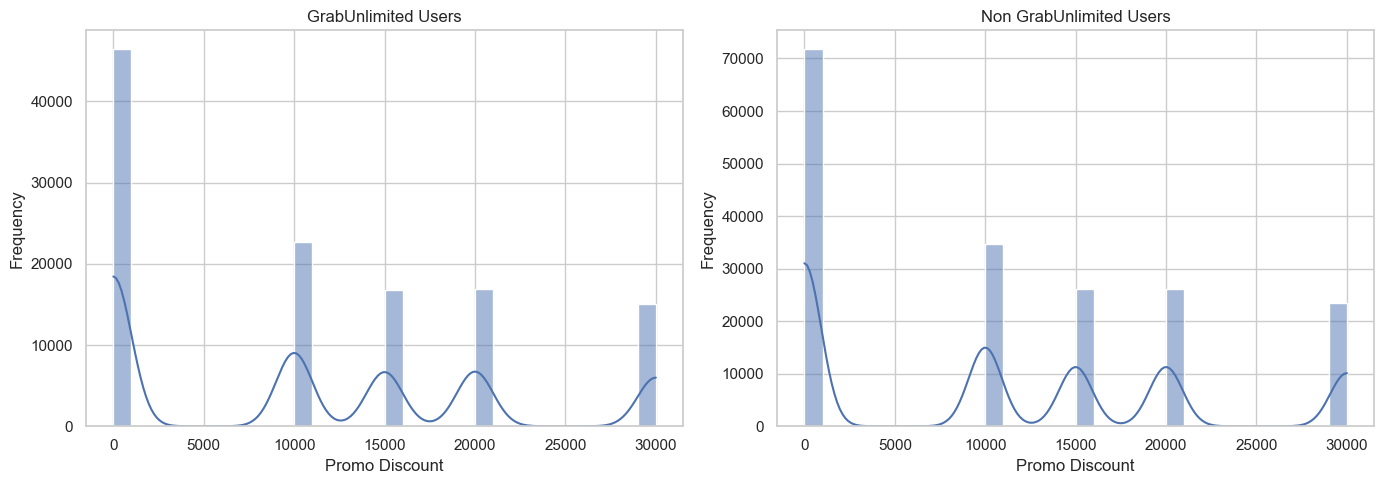

In [184]:
# (4.9.1.2) Visualize Distribution of Promo Discount for GrabUnlimited vs Non GrabUnlimited
# Step:
# - Create side-by-side histogram plots
# - Compare distribution of promo_discount between both groups
# - Helps to visually inspect skewness and potential outliers


# Create canvas with 2 subplots
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Histogram: GrabUnlimited users
sns.histplot(grab_unlimited, bins=30, kde=True, ax=ax[0])
ax[0].set_title("GrabUnlimited Users")
ax[0].set_xlabel("Promo Discount")
ax[0].set_ylabel("Frequency")

# Histogram: Non GrabUnlimited users
sns.histplot(non_grab_unlimited, bins=30, kde=True, ax=ax[1])
ax[1].set_title("Non GrabUnlimited Users")
ax[1].set_xlabel("Promo Discount")
ax[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In [185]:
# (4.9.1.3) Check Normality Assumption Using Shapiro-Wilk Test
# Step:
# - Perform Shapiro-Wilk test on both groups (GrabUnlimited & Non GrabUnlimited)
# - Determine whether data is normally distributed
# - If any group is not normal (p < 0.05), set normality = False

normality = True
alpha = 0.05

# GrabUnlimited normality test
_, p_gu = shapiro(grab_unlimited)
if p_gu < alpha:
    normality = False

# Non GrabUnlimited normality test
_, p_non = shapiro(non_grab_unlimited)
if p_non < alpha:
    normality = False

print(f"GrabUnlimited p-value     : {p_gu:.6f}")
print(f"Non GrabUnlimited p-value : {p_non:.6f}")
print(f"\nAssumption normality valid? {normality}")

GrabUnlimited p-value     : 0.000000
Non GrabUnlimited p-value : 0.000000

Assumption normality valid? False


/Users/zian/Desktop/Learn Code/Data Science And Machine Learning Purwadhika/Data Analytics Grab/grab/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 118019.
  res = hypotest_fun_out(*samples, **kwds)
/Users/zian/Desktop/Learn Code/Data Science And Machine Learning Purwadhika/Data Analytics Grab/grab/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 181981.
  res = hypotest_fun_out(*samples, **kwds)


In [186]:
# (4.9.1.4) Hypothesis Testing: Promo Discount Comparison (Parametric vs Non-Parametric)
# Step:
# - If data is normal → use Independent T-Test (Welch)
# - If data is not normal → use Mann-Whitney U Test
# - Alternative hypothesis: GrabUnlimited > Non GrabUnlimited

alpha = 0.05

H0 = "Gagal menolak H0: Rata-rata promo GrabUnlimited tidak lebih besar dari Non GrabUnlimited"
H1 = "Tolak H0: Rata-rata/median promo GrabUnlimited lebih besar dibanding Non GrabUnlimited"

print("=== Hypothesis Testing Result ===")

if normality:
    stat, p = ttest_ind(
        grab_unlimited,
        non_grab_unlimited,
        equal_var=False,
        alternative="greater"
    )
    test_name = "Independent T-Test (Welch)"
else:
    stat, p = mannwhitneyu(
        grab_unlimited,
        non_grab_unlimited,
        alternative="greater"
    )
    test_name = "Mann-Whitney U Test"

print(f"Test Used : {test_name}")
print(f"Statistic  : {stat:.6f}")
print(f"P-value    : {p:.6f}")

if p < alpha:
    print(f"\nConclusion: {H1}")
else:
    print(f"\nConclusion: {H0}")

=== Hypothesis Testing Result ===
Test Used : Mann-Whitney U Test
Statistic  : 10736108694.500000
P-value    : 0.544671

Conclusion: Gagal menolak H0: Rata-rata promo GrabUnlimited tidak lebih besar dari Non GrabUnlimited


## 4.10 Merchant Fraud Detection Hypothesis (User Concentration Anomaly Test)

### Business Question

Apakah merchant yang terindikasi fraud memiliki pola distribusi pelanggan (user diversity) yang berbeda dibandingkan merchant normal?

Secara spesifik:
- Apakah merchant yang masuk kategori suspected fraud memiliki jumlah unique users yang lebih rendah dibanding merchant lainnya?

---

### Hypothesis

- H₀ (Null Hypothesis): Tidak terdapat perbedaan jumlah unique users antara merchant suspected fraud dan merchant normal.
- H₁ (Alternative Hypothesis): Merchant suspected fraud memiliki jumlah unique users yang lebih rendah dibanding merchant normal.

---

### Statistical Test Result

```
Test Used  : Mann-Whitney U Test
Statistic  : 77535.500000
P-value    : 0.171970
```

---

### Conclusion

Karena p-value (0.171970) > 0.05, maka gagal menolak H₀.

Tidak terdapat bukti statistik yang cukup untuk menyatakan bahwa merchant suspected fraud memiliki jumlah unique users yang lebih rendah dibanding merchant normal.

---

### Business Interpretation

Hasil ini menunjukkan bahwa:

- Distribusi user antar merchant fraud dan non-fraud tidak memiliki perbedaan signifikan
- User diversity bukan indikator yang cukup kuat untuk mendeteksi merchant fraud
- Merchant yang terindikasi fraud kemungkinan masih memiliki pola user yang terlihat normal secara agregat

Hal ini mengindikasikan bahwa pelaku fraud kemungkinan:
- Menggunakan strategi multi-account (Sybil attack)
- Menyebarkan transaksi agar terlihat natural
- Menghindari pola sederhana seperti konsentrasi user rendah

---

### Key Insight

Fraud pattern tidak dapat diidentifikasi hanya dari satu dimensi seperti jumlah unique users.

Hal ini menunjukkan bahwa fraud bersifat multi-dimensional, sehingga diperlukan kombinasi fitur lain seperti:
- Promo abuse intensity
- Order velocity atau time-based anomaly
- Geo-location clustering
- Cancellation pattern analysis
- Cross-user behavioral similarity

---

### Final Takeaway

Meskipun secara intuitif merchant fraud diasumsikan memiliki jumlah user lebih sedikit, hasil analisis menunjukkan bahwa fraudster mampu meniru distribusi user normal.

Oleh karena itu, deteksi fraud tidak dapat dilakukan hanya berdasarkan user concentration, melainkan harus menggunakan pendekatan multi-feature anomaly detection.

In [187]:
# (4.10.1.1) Split Merchant Based on Fraud Indication
# Step:
# - merchant_overlap.index contains suspected fraud merchant_id
# - Compare user diversity between suspected fraud vs normal merchants

suspected_fraud_merchant = merchant_grouped[
    merchant_grouped["merchant_id"].isin(merchant_overlap.index)
]["unique_users"]

not_suspected_fraud_merchant = merchant_grouped[
    ~merchant_grouped["merchant_id"].isin(merchant_overlap.index)
]["unique_users"]

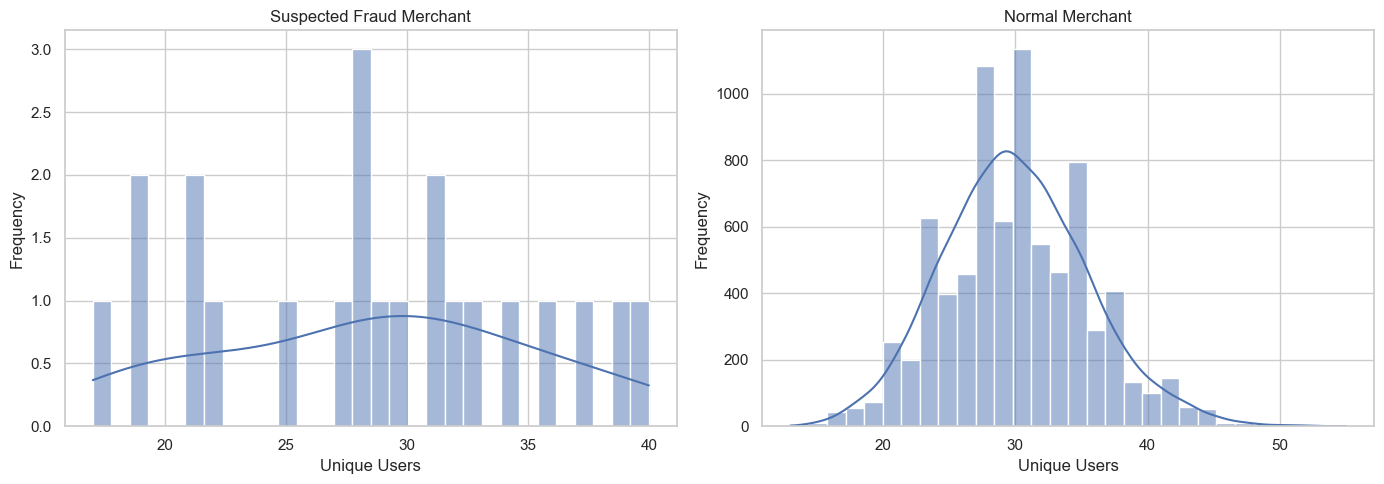

In [188]:
# (4.10.1.2) Visualize Distribution of Unique Users per Merchant
# Step:
# - Compare distribution between suspected fraud merchants and normal merchants
# - Detect skewness and potential anomalies

import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Suspected Fraud Merchant
sns.histplot(suspected_fraud_merchant, bins=30, kde=True, ax=ax[0])
ax[0].set_title("Suspected Fraud Merchant")
ax[0].set_xlabel("Unique Users")
ax[0].set_ylabel("Frequency")

# Normal Merchant
sns.histplot(not_suspected_fraud_merchant, bins=30, kde=True, ax=ax[1])
ax[1].set_title("Normal Merchant")
ax[1].set_xlabel("Unique Users")
ax[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In [189]:
# (4.10.1.3) Check Normality Assumption
# Step:
# - Test whether both groups follow normal distribution
# - If p-value < 0.05 → reject H0 (not normal)

from scipy.stats import shapiro

normality = True
alpha = 0.05

# Suspected fraud merchants
_, p_fraud = shapiro(suspected_fraud_merchant)
if p_fraud < alpha:
    normality = False

# Normal merchants
_, p_non = shapiro(not_suspected_fraud_merchant)
if p_non < alpha:
    normality = False

print(f"Suspected Fraud p-value : {p_fraud:.6f}")
print(f"Normal Merchant p-value : {p_non:.6f}")
print(f"\nAssumption normality valid? {normality}")

Suspected Fraud p-value : 0.609432
Normal Merchant p-value : 0.000000

Assumption normality valid? False


/Users/zian/Desktop/Learn Code/Data Science And Machine Learning Purwadhika/Data Analytics Grab/grab/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 7978.
  res = hypotest_fun_out(*samples, **kwds)


In [190]:
# (4.10.1.4) Fraud vs Non-Fraud Merchant Comparison
# Step:
# - Since data is not normally distributed, use Mann-Whitney U Test
# - Compare unique user distribution between groups

from scipy.stats import ttest_ind, mannwhitneyu

alpha = 0.05

H0 = "Gagal menolak H0: Tidak terdapat perbedaan jumlah unique users antara merchant fraud dan non-fraud"
H1 = "Tolak H0: Merchant suspected fraud memiliki jumlah unique users yang lebih rendah"

print("=== Hypothesis Testing Result ===")

if normality:
    stat, p = ttest_ind(
        suspected_fraud_merchant,
        not_suspected_fraud_merchant,
        equal_var=False,
        alternative="less"
    )
    test_name = "Independent T-Test (Welch)"
else:
    stat, p = mannwhitneyu(
        suspected_fraud_merchant,
        not_suspected_fraud_merchant,
        alternative="less"
    )
    test_name = "Mann-Whitney U Test"

print(f"Test Used  : {test_name}")
print(f"Statistic  : {stat:.6f}")
print(f"P-value    : {p:.6f}")

if p < alpha:
    print(f"\nConclusion: {H1}")
else:
    print(f"\nConclusion: {H0}")

=== Hypothesis Testing Result ===
Test Used  : Mann-Whitney U Test
Statistic  : 77535.500000
P-value    : 0.171970

Conclusion: Gagal menolak H0: Tidak terdapat perbedaan jumlah unique users antara merchant fraud dan non-fraud


In [191]:
# (4.11.1.1) Total Orders and Total Promo Analysis (All Status)
# Step:
# - Calculate the total number of entries in the cleaned food orders dataset
# - Aggregate the overall promotional budget spent across all transaction statuses

total_promo_all = df_food_orders_cleaned["promo_discount"].sum()

print("=== Overall Order & Promo Summary ===")
print(f"Total Order: {len(df_food_orders_cleaned)}")
print(f"Promo Discount Used (All Orders): Rp {total_promo_all:,.0f}")
print("-" * 50)


# (4.11.1.2) Cancelled and Failed Orders Analysis
# Step:
# - Create a boolean mask filtering orders with 'Cancelled' or 'Failed' status
# - Count the total failed transactions and sum the burnt promotional discount

cancelled_or_failed = (df_food_orders_cleaned["order_status"] == "Cancelled") | (df_food_orders_cleaned["order_status"] == "Failed")
total_promo_cancelled = df_food_orders_cleaned[cancelled_or_failed]["promo_discount"].sum()

print("=== Cancelled / Failed Orders Summary ===")
print(f"Total Order Cancelled/Failed: {cancelled_or_failed.sum()}")
print(f"Promo Discount Used (Cancelled/Failed): Rp {total_promo_cancelled:,.0f}")
print("-" * 50)


# (4.11.1.3) Completed Orders Analysis
# Step:
# - Filter the dataset for successfully fulfilled transactions ('Completed')
# - Measure the net effective promotional discount used by customers

completed = df_food_orders_cleaned["order_status"] == "Completed"
total_promo_completed = df_food_orders_cleaned[completed]["promo_discount"].sum()

print("=== Completed Orders Summary ===")
print(f"Total Order Completed: {completed.sum()}")
print(f"Promo Discount Used (Completed): Rp {total_promo_completed:,.0f}")
print("-" * 50)


# (4.11.1.4) Platform User and Merchant Metrics
# Step:
# - Calculate the total unique user base registered in the system
# - Calculate the total active merchant network available on the platform

print("=== Platform Entites Summary ===")
print(f"Total Users: {len(df_users_cleaned)}")
print(f"Total Merchant: {len(df_merchants_cleaned)}")
print("-" * 50)

=== Overall Order & Promo Summary ===
Total Order: 300000
Promo Discount Used (All Orders): Rp 3,232,490,000
--------------------------------------------------
=== Cancelled / Failed Orders Summary ===
Total Order Cancelled/Failed: 59907
Promo Discount Used (Cancelled/Failed): Rp 611,295,000
--------------------------------------------------
=== Completed Orders Summary ===
Total Order Completed: 240093
Promo Discount Used (Completed): Rp 2,621,195,000
--------------------------------------------------
=== Platform Entites Summary ===
Total Users: 40000
Total Merchant: 8000
--------------------------------------------------


/var/folders/jm/cnb7h87d1nddqbjwdl1p5s_80000gn/T/ipykernel_12103/3111503208.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax_bar = sns.barplot(


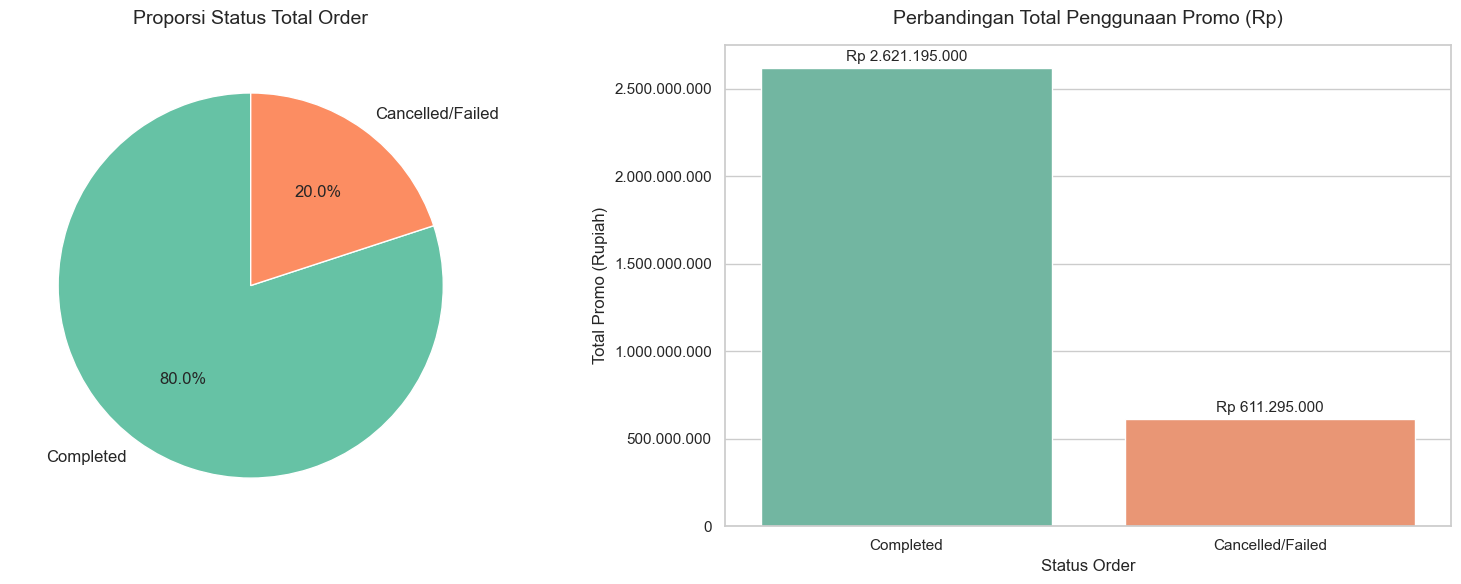

In [192]:
# (4.11.1.5) Order Status Share and Promo Burn Visualization
# Step:
# - Prepare aggregate data for Completed vs Cancelled/Failed transactions
# - Generate a Pie Chart to display the percentage distribution of order statuses
# - Generate a Bar Chart to compare the total promo discount spent between statuses
# - Format numerical values on the bar chart into Indonesian Rupiah (Rp) string format

import matplotlib.pyplot as plt
import seaborn as sns

# 1. Menghitung metric summary untuk visualisasi
count_completed = completed.sum()
count_failed = cancelled_or_failed.sum()

promo_completed = total_promo_completed
promo_failed = total_promo_cancelled

# 2. Setup canvas untuk 2 plot berdampingan (1 baris, 2 kolom)
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ------------------------------------------------------------------------------
# PLOT 1: PIE CHART - Sebaran Jumlah Order
# ------------------------------------------------------------------------------
labels_pie = ["Completed", "Cancelled/Failed"]
sizes_pie = [count_completed, count_failed]
colors_pie = sns.color_palette("Set2")[:2]

axes[0].pie(
    sizes_pie, 
    labels=labels_pie, 
    autopct="%1.1f%%", 
    startangle=90, 
    colors=colors_pie,
    textprops={'fontsize': 12}
)
axes[0].set_title("Proporsi Status Total Order", fontsize=14, pad=15)

# ------------------------------------------------------------------------------
# PLOT 2: BAR CHART - Perbandingan Burn Promo (Rupiah)
# ------------------------------------------------------------------------------
labels_bar = ["Completed", "Cancelled/Failed"]
promo_values = [promo_completed, promo_failed]

ax_bar = sns.barplot(
    x=labels_bar, 
    y=promo_values, 
    ax=axes[1], 
    palette="Set2"
)

# Tambahkan label nominal Rupiah di atas masing-masing bar
for container in ax_bar.containers:
    ax_bar.bar_label(
        container, 
        fmt=lambda x: f"Rp {x:,.0f}".replace(",", "."), 
        padding=3, 
        fontsize=11
    )

# Format Sumbu Y agar rapi dengan format ribuan
ax_bar.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"{x:,.0f}".replace(",", ".")))

axes[1].set_title("Perbandingan Total Penggunaan Promo (Rp)", fontsize=14, pad=15)
axes[1].set_ylabel("Total Promo (Rupiah)", fontsize=12)
axes[1].set_xlabel("Status Order", fontsize=12)

# 3. Render Akhir
plt.tight_layout()
plt.show()

/var/folders/jm/cnb7h87d1nddqbjwdl1p5s_80000gn/T/ipykernel_12103/3535654811.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


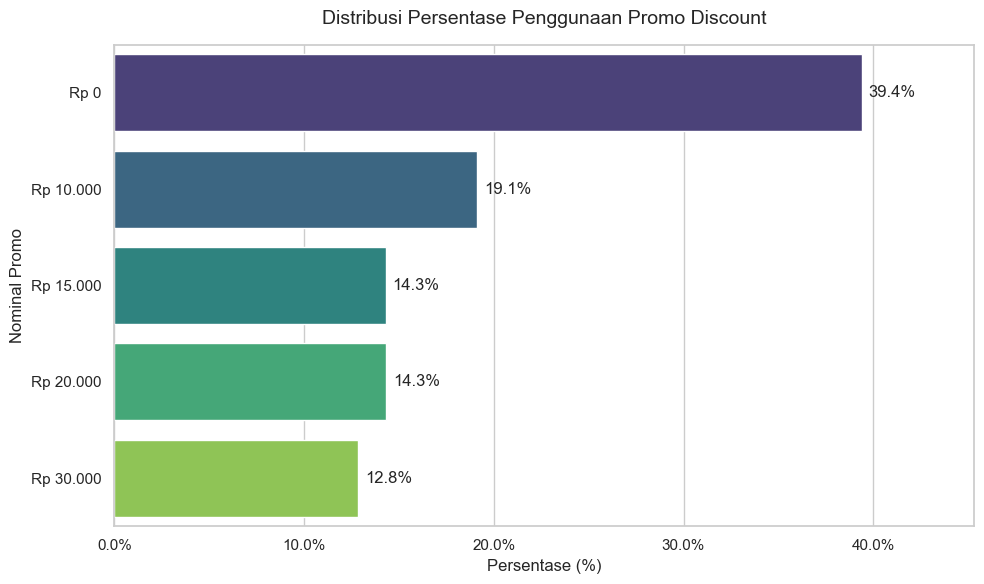

In [193]:
# (4.12.1.1) Promo Discount Distribution Visualization
# Step:
# - Calculate the percentage distribution of each promotional discount value
# - Sort the distribution by the nominal promo amount in ascending order
# - Convert nominal values into Indonesian Rupiah (Rp) string format for better readability
# - Generate a horizontal bar plot using Seaborn with percentage labels attached to the end of each bar

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# 1. Hitung persentase data dan reset index
promo_counts = (
    df_food_orders_cleaned["promo_discount"]
    .value_counts(normalize=True)
    .reset_index()
)
promo_counts.columns = ["promo_discount", "percentage"]

# 2. Urutkan berdasarkan nominal diskon (dari terkecil ke terbesar)
promo_counts = promo_counts.sort_values(by="promo_discount", ascending=True)

# 3. Ubah value di dalam DataFrame langsung menjadi format Rupiah string
promo_counts["promo_discount"] = promo_counts["promo_discount"].apply(
    lambda x: f"Rp {x:,.0f}".replace(",", ".")
)

# 4. Atur gaya visualisasi
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# 5. Buat barplot (Horizontal: x=persentase, y=nominal diskon Rupiah)
ax = sns.barplot(
    data=promo_counts,
    x="percentage",
    y="promo_discount",
    palette="viridis",
)

# 6. Tambahkan label persentase langsung di ujung bar
for container in ax.containers:
    ax.bar_label(container, fmt=lambda x: f"{x*100:.1f}%", padding=5)

# 7. Format sumbu X menjadi persentase (%)
ax.xaxis.set_major_formatter(ticker.PercentFormatter(xmax=1.0))

# 8. Tambahkan Judul dan Label Sumbu
plt.title("Distribusi Persentase Penggunaan Promo Discount", fontsize=14, pad=15)
plt.xlabel("Persentase (%)", fontsize=12)
plt.ylabel("Nominal Promo", fontsize=12)

# 9. Atur batas sumbu X agar label di ujung bar tidak terpotong
plt.xlim(0, promo_counts["percentage"].max() * 1.15)

plt.tight_layout()
plt.show()

## **Section 5. Conclusion and Recommendation**

**5.1 Conclusion**

**Data Quality Issues**
- The order_status column contained 7 different text variations that actually represented only 3 real statuses (Completed, Cancelled, Failed), caused by mixed language and inconsistent capitalization.
- 40.24% of all cancelled orders had no cancellation reason recorded, making it difficult for the operations team to distinguish genuine issues from fraud-related cancellations.
- The promo_discount column contained invalid placeholder values (e.g. -5000 and 9999999) that had to be cleaned before analysis.

**Fraud & Anomaly Findings**
- Cross-checking both anomaly signals (high cancellation rate and timestamp anomaly) narrowed the list down to 22 "super high-risk" merchants, resulting in Rp 1,260,000 in confirmed subsidy losses across 42 fraudulent orders. Each order came from a different user account, suggesting a Sybil attack in which multiple fake accounts were created to distribute fraudulent orders and avoid detection.
- About 3.20% of all orders, or 4.00% of completed orders, were recorded as completed before the driver arrived, an impossible sequence in a real delivery. The anomaly was heavily concentrated among orders using the highest promo discount of Rp 30,000, with a rate of 24.95%, far higher than other promo tiers. This indicates a likely system loophole being exploited for promo abuse, exposing up to Rp 288,090,000 in subsidy risk across 5,635 affected merchants.
- About 40.24% of cancelled orders had no recorded cancellation reason. This missing information makes it difficult to distinguish legitimate cancellations from potentially fraudulent ones, reducing the effectiveness of fraud detection and slowing investigation and reporting.
- A total of 36 merchants were identified as high risk due to an unusually high cancellation and failure rate among GrabUnlimited orders, resulting in an estimated Rp 6,610,000 in wasted promo subsidy. Combined with the concentration of timestamp anomalies in the highest promo tier of Rp 30,000, this indicates that fraud is more likely to target higher subsidy values because they offer greater financial returns per fraudulent transaction.

**5.2 Recommendation**

- **Prioritize investigation** of the 22 "super high-risk" merchants and their associated 42 user accounts, since they are confirmed on two independent fraud signals at once.
- **Add a system-level validation rule** to prevent an order from being marked "Completed" before the driver's arrival timestamp is recorded, closing the loophole being exploited for promo abuse.
- **Make the cancellation reason field mandatory** at the point of cancellation to eliminate the current 40.24% missing-reason rate and support faster fraud investigation.
- **Monitor high-value promo tiers (e.g. Rp 30,000) more closely**, since fraud activity is disproportionately concentrated in the largest subsidy amount.